In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mordred


In [3]:
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors


In [4]:
dataset = pd.read_excel('adding data.xlsx')
dataset.shape

(89, 2)

In [5]:
from mordred import Calculator, descriptors

In [6]:
dataset.head()

,SMILES,Cc
0,CCCCCCOCCOCCO,2.4
1,CCCCCCOCCOCCOCCO,0.1
2,CCCCCCOCCOCCOCCOCCO,-1.6
3,CCCCCCCCCCCCOCCOCCOCCOCCOCCO,0.8
4,CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO,-0.7


In [7]:
def canonical_smiles(smiles):
    mols = [Chem.MolFromSmiles(smi) for smi in smiles] 
    smiles = [Chem.MolToSmiles(mol) for mol in mols]
    return smiles

In [8]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

In [9]:
Canon_SMILES = canonical_smiles(dataset.SMILES)
len(Canon_SMILES)

[11:10:06] WARNING: not removing hydrogen atom without neighbors


89

In [10]:
dataset['SMILES'] = Canon_SMILES
dataset

,SMILES,Cc
0,CCCCCCOCCOCCO,2.4
1,CCCCCCOCCOCCOCCO,0.1
2,CCCCCCOCCOCCOCCOCCO,-1.6
3,CCCCCCCCCCCCOCCOCCOCCOCCOCCO,0.8
4,CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO,-0.7
...,...,...
84,CC(C)CCCC(C)CCCC(C)OCCOCCOCCOCCOCCOCCOCCOCCO,-1.8
85,CC(C)CCCC(C)CCCC(C)OCCOCCOCCOCCOCCOCCOCCOC(=O)...,-2.5
86,CC(C)CCCC(C)CCCC(C)CCOCC(C)COCC(C)COCCOCCOCCOC...,-1.5
87,CCCCCCCCCCC(C)COCC(C)COCC(C)COCC(C)COCC(C)COCC...,-1.0


In [11]:
duplicates_smiles = dataset[dataset['SMILES'].duplicated()]['SMILES'].values
len(duplicates_smiles)

0

In [12]:
dataset[dataset['SMILES'].isin(duplicates_smiles)].sort_values(by=['SMILES'])

,SMILES,Cc


In [13]:
dataset_new = dataset.drop_duplicates(subset=['SMILES'])
len(dataset_new)

89

In [14]:
dataset_new

,SMILES,Cc
0,CCCCCCOCCOCCO,2.4
1,CCCCCCOCCOCCOCCO,0.1
2,CCCCCCOCCOCCOCCOCCO,-1.6
3,CCCCCCCCCCCCOCCOCCOCCOCCOCCO,0.8
4,CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO,-0.7
...,...,...
84,CC(C)CCCC(C)CCCC(C)OCCOCCOCCOCCOCCOCCOCCOCCO,-1.8
85,CC(C)CCCC(C)CCCC(C)OCCOCCOCCOCCOCCOCCOCCOC(=O)...,-2.5
86,CC(C)CCCC(C)CCCC(C)CCOCC(C)COCC(C)COCCOCCOCCOC...,-1.5
87,CCCCCCCCCCC(C)COCC(C)COCC(C)COCC(C)COCC(C)COCC...,-1.0


In [ ]:
def RDkit_descriptors(smiles):
    mols = [Chem.MolFromSmiles(i) for i in smiles] 
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    desc_names = calc.GetDescriptorNames()
    
    Mol_descriptors =[]
    for mol in mols:
        # add hydrogens to molecules
        mol=Chem.AddHs(mol)
        # Calculate all 200 descriptors for each molecule
        descriptors = calc.CalcDescriptors(mol)
        Mol_descriptors.append(descriptors)
    return Mol_descriptors,desc_names 

# Function call
Mol_descriptors,desc_names = RDkit_descriptors(dataset_new['SMILES'])

[11:10:06] WARNING: not removing hydrogen atom without neighbors
[11:10:06] DEPRECATION WARNING: please use MorganGenerator
[11:10:06] DEPRECATION WARNING: please use MorganGenerator
[11:10:06] DEPRECATION WARNING: please use MorganGenerator
[11:10:06] 

****
Pre-condition Violation
bad result vector size
Violation occurred on line 42 in file C:\rdkit\build\temp.win-amd64-cpython-312\Release\rdkit\Code\GraphMol\Descriptors\Crippen.cpp
Failed Expression: logpContribs.size() == mol.getNumAtoms() && mrContribs.size() == mol.getNumAtoms()
****

[11:10:06] 

****
Pre-condition Violation
bad result vector size
Violation occurred on line 42 in file C:\rdkit\build\temp.win-amd64-cpython-312\Release\rdkit\Code\GraphMol\Descriptors\Crippen.cpp
Failed Expression: logpContribs.size() == mol.getNumAtoms() && mrContribs.size() == mol.getNumAtoms()
****

[11:10:06] 

****
Pre-condition Violation
bad result vector size
Violation occurred on line 42 in file C:\rdkit\build\temp.win-amd64-cpython-312\Rel

In [16]:
df_with_200_descriptors = pd.DataFrame(Mol_descriptors,columns=desc_names)
df_with_200_descriptors

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,7.757794,7.757794,3.404202,-4.468808,0.531644,46.461538,190.283,168.107,190.156895,80,...,0,0,0,0,0,0,0,0,0,0
1,7.823703,7.823703,3.403794,-4.583189,0.491822,45.500000,234.336,208.128,234.183109,98,...,0,0,0,0,0,0,0,0,0,0
2,7.865362,7.865362,3.403120,-4.658032,0.434848,44.842105,278.389,248.149,278.209324,116,...,0,0,0,0,0,0,0,0,0,0
3,8.240295,8.240295,3.398471,-5.274636,0.231360,46.857143,406.604,360.236,406.329439,170,...,0,0,0,0,0,0,0,0,0,0
4,8.334186,8.334186,3.397058,-5.445258,0.123133,46.444444,522.764,464.300,522.413169,218,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,8.740718,8.740718,3.396790,-5.753519,0.123640,48.315789,552.790,492.310,552.423734,230,...,0,0,0,0,0,0,0,0,0,0
85,10.675608,10.675608,2.810891,-5.743433,0.097071,45.421053,551.738,496.298,551.380072,228,...,0,0,0,0,0,0,0,0,0,0
86,10.996388,10.996388,2.900237,-6.032038,0.087746,49.288889,649.927,580.375,649.489622,270,...,0,0,0,0,0,0,0,0,0,0
87,11.047237,11.047237,3.242958,-6.382615,0.032630,51.725806,916.330,820.570,915.644802,374,...,0,0,0,0,0,0,0,0,0,0


In [17]:


# Example: Combining original data with descriptors
# Assuming 'df' is your original DataFrame with 'SMILES' and 'Cc'
# 'df_descriptors' is the DataFrame with molecular descriptors

df_combined = pd.concat([dataset_new, df_with_200_descriptors], axis=1)

# Display the first few rows to verify
print(df_combined.head())


                                 SMILES   Cc  MaxAbsEStateIndex  \
0                         CCCCCCOCCOCCO  2.4           7.757794   
1                      CCCCCCOCCOCCOCCO  0.1           7.823703   
2                   CCCCCCOCCOCCOCCOCCO -1.6           7.865362   
3          CCCCCCCCCCCCOCCOCCOCCOCCOCCO  0.8           8.240295   
4  CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO -0.7           8.334186   

   MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed        SPS  \
0        7.757794           3.404202       -4.468808  0.531644  46.461538   
1        7.823703           3.403794       -4.583189  0.491822  45.500000   
2        7.865362           3.403120       -4.658032  0.434848  44.842105   
3        8.240295           3.398471       -5.274636  0.231360  46.857143   
4        8.334186           3.397058       -5.445258  0.123133  46.444444   

     MolWt  HeavyAtomMolWt  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0  190.283         168.107  ...           0             0    

In [18]:
def morgan_fpts(data):
    Morgan_fpts = []
    for i in data:
        mol = Chem.MolFromSmiles(i) 
        fpts =  AllChem.GetMorganFingerprintAsBitVect(mol,2,2048)
        mfpts = np.array(fpts)
        Morgan_fpts.append(mfpts)  
    return np.array(Morgan_fpts)

In [19]:
Morgan_fpts = morgan_fpts(dataset_new['SMILES'])
Morgan_fpts.shape

[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerator
[11:10:25] DEPRECATION WARNING: please use MorganGenerat

(89, 2048)

In [20]:
Morgan_fingerprints = pd.DataFrame(Morgan_fpts,columns=['Col_{}'.format(i) for i in range(Morgan_fpts.shape[1])])
Morgan_fingerprints

,Col_0,Col_1,Col_2,Col_3,Col_4,Col_5,Col_6,Col_7,Col_8,Col_9,...,Col_2038,Col_2039,Col_2040,Col_2041,Col_2042,Col_2043,Col_2044,Col_2045,Col_2046,Col_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
85,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
86,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
87,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
def All_Mordred_descriptors(data):
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [Chem.MolFromSmiles(smi) for smi in data]
    
    # pandas df
    df = calc.pandas(mols)
    return df

In [22]:
mordred_descriptors = All_Mordred_descriptors(dataset_new['SMILES'])

[11:10:25] WARNING: not removing hydrogen atom without neighbors
  0%|          | 0/89 [00:00<?, ?it/s][11:10:26] WARNING: not removing hydrogen atom without neighbors
[11:10:26] WARNING: not removing hydrogen atom without neighbors
[11:10:26] WARNING: not removing hydrogen atom without neighbors
  4%|▍         | 4/89 [00:03<05:16,  3.72s/it]

c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  9%|▉         | 8/89 [00:04<00:31,  2.59it/s]

c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 97%|█████████▋| 86/89 [00:05<00:00, 45.06it/s]

c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc

100%|██████████| 89/89 [00:05<00:00, 15.87it/s]


In [23]:
mordred_descriptors.shape

(89, 1826)

In [24]:

mordred_descriptors

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,15.750491,1.949856,3.899712,15.750491,1.211576,3.372523,...,7.826044,40.245095,190.156895,5.433054,364,10,46.0,44.0,4.75,3.500000
1,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,19.675903,1.965946,3.931892,19.675903,1.229744,3.583262,...,8.089789,44.454249,234.183109,5.575788,680,13,58.0,56.0,5.5,4.250000
2,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,23.412409,1.975377,3.950753,23.412409,1.232232,3.757227,...,8.298291,48.426412,278.209324,5.677741,1140,16,70.0,68.0,6.25,5.000000
3,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,34.942008,1.988276,3.976552,34.942008,1.247929,4.148608,...,8.745921,59.551757,406.329439,5.490938,3654,25,106.0,104.0,8.5,7.250000
4,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,45.124017,1.992795,3.98559,45.124017,1.253445,4.401614,...,9.024131,68.892968,522.413169,5.557587,7770,33,138.0,136.0,10.5,9.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,46.274555,2.097518,4.195036,46.274555,1.217751,4.463265,...,9.315151,71.745380,552.423734,5.636977,8649,37,152.0,152.0,12.833333,9.416667
85,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,1,0,45.7868,2.097518,4.195036,45.7868,1.204916,4.465602,...,9.360913,71.876595,551.380072,5.928818,8614,37,154.0,154.0,13.444444,9.250000
86,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,1,0,54.136502,2.112738,4.225477,54.136502,1.203033,4.638181,...,9.627009,79.965461,649.489622,5.697277,13618,46,186.0,188.0,16.416667,10.833333
87,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,1,0,73.94842,2.129756,4.259512,73.94842,1.192716,4.964127,...,10.101231,98.948700,915.644802,5.832132,33436,67,264.0,270.0,23.201389,14.708333


In [25]:


# Example: Combining original data with descriptors
# Assuming 'df' is your original DataFrame with 'SMILES' and 'Cc'
# 'df_descriptors' is the DataFrame with molecular descriptors

df_mordreed = pd.concat([dataset_new, mordred_descriptors], axis=1)

# Display the first few rows to verify
print(df_mordreed.head())


                                 SMILES   Cc  \
0                         CCCCCCOCCOCCO  2.4   
1                      CCCCCCOCCOCCOCCO  0.1   
2                   CCCCCCOCCOCCOCCOCCO -1.6   
3          CCCCCCCCCCCCOCCOCCOCCOCCOCCO  0.8   
4  CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO -0.7   

                                                 ABC  \
0  module 'numpy' has no attribute 'float'.\n`np....   
1  module 'numpy' has no attribute 'float'.\n`np....   
2  module 'numpy' has no attribute 'float'.\n`np....   
3  module 'numpy' has no attribute 'float'.\n`np....   
4  module 'numpy' has no attribute 'float'.\n`np....   

                                               ABCGG  nAcid  nBase    SpAbs_A  \
0  module 'numpy' has no attribute 'float'.\n`np....      0      0  15.750491   
1  module 'numpy' has no attribute 'float'.\n`np....      0      0  19.675903   
2  module 'numpy' has no attribute 'float'.\n`np....      0      0  23.412409   
3  module 'numpy' has no attribute 'float'.\n`np..

In [26]:
# Define the output file path
output_excel_mordreed = 'surfactant_descriptors_mordreed.xlsx'

# Save the DataFrame to Excel
df_mordreed.to_excel(output_excel_mordreed, index=False)

print(f"Data successfully saved to {output_excel_mordreed}")


Data successfully saved to surfactant_descriptors_mordreed.xlsx


In [27]:
# Define the output file path
output_csv_path = 'surfactant_descriptors.csv'

# Save the DataFrame to CSV
df_combined.to_csv(output_csv_path, index=False)

print(f"Data successfully saved to {output_csv_path}")


Data successfully saved to surfactant_descriptors.csv


In [28]:
# Define the output file path
output_excel_path = 'surfactant_descriptors.xlsx'

# Save the DataFrame to Excel
df_combined.to_excel(output_excel_path, index=False)

print(f"Data successfully saved to {output_excel_path}")


Data successfully saved to surfactant_descriptors.xlsx


In [29]:
# Load the saved Excel to verify
df_loaded = pd.read_excel('surfactant_descriptors_remark.xlsx')
print(df_loaded.head())
print(df_loaded.info())


                                 SMILES   Cc  MaxAbsEStateIndex  \
0                         CCCCCCOCCOCCO  2.4           7.757794   
1                      CCCCCCOCCOCCOCCO  0.1           7.823703   
2                   CCCCCCOCCOCCOCCOCCO -1.6           7.865362   
3          CCCCCCCCCCCCOCCOCCOCCOCCOCCO  0.8           8.240295   
4  CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO -0.7           8.334186   

   MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed        SPS  \
0        7.757794           3.404202       -4.468808  0.531644  46.461538   
1        7.823703           3.403794       -4.583189  0.491822  45.500000   
2        7.865362           3.403120       -4.658032  0.434848  44.842105   
3        8.240295           3.398471       -5.274636  0.231360  46.857143   
4        8.334186           3.397058       -5.445258  0.123133  46.444444   

     MolWt  HeavyAtomMolWt  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0  190.283         168.107  ...           0             0    

In [30]:
df_loaded.shape

(84, 212)

In [31]:
# Load the saved Excel to verify
df_loaded_mordreed = pd.read_excel('surfactant_descriptors_mordreed_remark.xlsx')
print(df_loaded_mordreed.head())
print(df_loaded_mordreed.info())



                  SMILES   Cc  \
0          CCCCCCOCCOCCO  2.4   
1       CCCCCCOCCOCCOCCO  0.1   
2    CCCCCCOCCOCCOCCOCCO -1.6   
3     CCCCCCCCOCCOCCOCCO  1.8   
4  CCCCCCCCOCCOCCOCCOCCO  0.3   

                                                 ABC  \
0  module 'numpy' has no attribute 'float'.\n`np....   
1  module 'numpy' has no attribute 'float'.\n`np....   
2  module 'numpy' has no attribute 'float'.\n`np....   
3  module 'numpy' has no attribute 'float'.\n`np....   
4  module 'numpy' has no attribute 'float'.\n`np....   

                                               ABCGG  nAcid  nBase    SpAbs_A  \
0  module 'numpy' has no attribute 'float'.\n`np....      0      0  15.750491   
1  module 'numpy' has no attribute 'float'.\n`np....      0      0  19.675903   
2  module 'numpy' has no attribute 'float'.\n`np....      0      0  23.412409   
3  module 'numpy' has no attribute 'float'.\n`np....      0      0  22.219131   
4  module 'numpy' has no attribute 'float'.\n`np....      0

In [32]:
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GridSearchCV

In [33]:
# Define a function to build the ANN model
def build_ann_model(optimizer='adam', activation='relu', neurons=32):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_dim=X_train.shape[1]))
    model.add(Dense(neurons, activation=activation))
    model.add(Dense(1, activation='linear'))  # For regression
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

In [34]:
from scikeras.wrappers import KerasRegressor

# Initialize the ANN model
ann = KerasRegressor(model=build_ann_model, verbose=0)

In [35]:
# Define the hyperparameter grid for GridSearchCV
param_grid = {
    'batch_size': [16, 32],
    'epochs': [50, 100],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'tanh'],
    'neurons': [32, 64]
}


In [36]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid = GridSearchCV(
    estimator=ann,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1  # Utilize all available cores
)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [38]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [39]:
# Define feature matrix X and target vector y
X = df_loaded.drop(['Cc'], axis=1)  # Features include SMILES and descriptors
y = df_loaded['Cc']  # Target variable

# Display the first few rows
print(X.head())
print(y.head())


                                 SMILES  MaxAbsEStateIndex  MaxEStateIndex  \
0                         CCCCCCOCCOCCO           7.757794        7.757794   
1                      CCCCCCOCCOCCOCCO           7.823703        7.823703   
2                   CCCCCCOCCOCCOCCOCCO           7.865362        7.865362   
3          CCCCCCCCCCCCOCCOCCOCCOCCOCCO           8.240295        8.240295   
4  CCCCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO           8.334186        8.334186   

   MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  \
0           3.404202       -4.468808  0.531644  46.461538  190.283   
1           3.403794       -4.583189  0.491822  45.500000  234.336   
2           3.403120       -4.658032  0.434848  44.842105  278.389   
3           3.398471       -5.274636  0.231360  46.857143  406.604   
4           3.397058       -5.445258  0.123133  46.444444  522.764   

   HeavyAtomMolWt  ExactMolWt  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0         168.107  190.156895  ...

In [40]:
df_loaded.shape

(84, 212)

In [41]:
# Identify numeric columns
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric Columns: {numeric_cols}")
print(f"Non-Numeric Columns: {non_numeric_cols}")


Numeric Columns: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 

In [42]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns
X_numeric = X[numeric_cols]
X_numeric_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=numeric_cols)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed = pd.concat([X[non_numeric_cols], X_numeric_imputed], axis=1)

# Verify that there are no missing values
print("Missing values after imputation:")
print(X_imputed.isnull().sum())


c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['BCUT2D_MWHI' 'BCUT2D_MWLOW' 'BCUT2D_CHGHI' 'BCUT2D_CHGLO'
 'BCUT2D_LOGPHI' 'BCUT2D_LOGPLOW' 'BCUT2D_MRHI' 'BCUT2D_MRLOW']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


ValueError: Shape of passed values is (84, 202), indices imply (84, 210)

In [ ]:
# Check the data types of the numeric columns
print("Data Types of Numeric Columns:")
print(X_numeric.dtypes)


Data Types of Numeric Columns:
MaxAbsEStateIndex    float64
MaxEStateIndex       float64
MinAbsEStateIndex    float64
MinEStateIndex       float64
qed                  float64
                      ...   
fr_thiazole            int64
fr_thiocyan            int64
fr_thiophene           int64
fr_unbrch_alkane       int64
fr_urea                int64
Length: 210, dtype: object


In [ ]:
# Identify non-numeric columns in numeric_cols
non_numeric_in_numeric = X_numeric.select_dtypes(exclude=['number']).columns.tolist()

print(f"Non-Numeric Columns in Numeric Features: {non_numeric_in_numeric}")


Non-Numeric Columns in Numeric Features: []


In [ ]:
# Attempt to convert non-numeric columns to numeric, coercing errors to NaN
for col in non_numeric_in_numeric:
    X_numeric[col] = pd.to_numeric(X_numeric[col], errors='coerce')
    print(f"Converted column '{col}' to numeric.")


In [ ]:
# Re-check the data types after conversion
print("Data Types After Conversion:")
print(X_numeric.dtypes)


Data Types After Conversion:
MaxAbsEStateIndex    float64
MaxEStateIndex       float64
MinAbsEStateIndex    float64
MinEStateIndex       float64
qed                  float64
                      ...   
fr_thiazole            int64
fr_thiocyan            int64
fr_thiophene           int64
fr_unbrch_alkane       int64
fr_urea                int64
Length: 210, dtype: object


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns
try:
    X_numeric_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=numeric_cols)
    print("Imputation successful.")
except ValueError as e:
    print(f"Error during imputation: {e}")


Error during imputation: Shape of passed values is (84, 202), indices imply (84, 210)


c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['BCUT2D_MWHI' 'BCUT2D_MWLOW' 'BCUT2D_CHGHI' 'BCUT2D_CHGLO'
 'BCUT2D_LOGPHI' 'BCUT2D_LOGPLOW' 'BCUT2D_MRHI' 'BCUT2D_MRLOW']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [ ]:
# Identify non-numeric columns within numeric_cols
non_numeric_in_numeric = X_numeric.select_dtypes(exclude=['number']).columns.tolist()
print(f"\nNon-Numeric Columns in Numeric Features: {non_numeric_in_numeric}")

# Convert non-numeric columns to numeric, coercing errors to NaN
for col in non_numeric_in_numeric:
    X_numeric[col] = pd.to_numeric(X_numeric[col], errors='coerce')
    print(f"Converted column '{col}' to numeric.")



Non-Numeric Columns in Numeric Features: []


In [ ]:
# Identify columns with all NaN values
cols_all_nan = [col for col in non_numeric_in_numeric if X_numeric[col].isna().all()]
print(f"\nColumns with all NaNs: {cols_all_nan}")

# Drop these columns from X_numeric
if cols_all_nan:
    X_numeric = X_numeric.drop(columns=cols_all_nan)
    print(f"Dropped columns with all NaNs: {cols_all_nan}")



Columns with all NaNs: []


In [ ]:
# Re-check data types after conversion
print("\nData Types After Conversion:")
print(X_numeric.dtypes)



Data Types After Conversion:
MaxAbsEStateIndex    float64
MaxEStateIndex       float64
MinAbsEStateIndex    float64
MinEStateIndex       float64
qed                  float64
                      ...   
fr_thiazole            int64
fr_thiocyan            int64
fr_thiophene           int64
fr_unbrch_alkane       int64
fr_urea                int64
Length: 210, dtype: object


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns within a try-except block
try:
    X_numeric_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=X_numeric.columns)
    print("Imputation successful.")
except ValueError as e:
    print(f"Error during imputation: {e}")


Error during imputation: Shape of passed values is (84, 202), indices imply (84, 210)


c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['BCUT2D_MWHI' 'BCUT2D_MWLOW' 'BCUT2D_CHGHI' 'BCUT2D_CHGLO'
 'BCUT2D_LOGPHI' 'BCUT2D_LOGPLOW' 'BCUT2D_MRHI' 'BCUT2D_MRLOW']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [ ]:
# Identify columns with all NaN values in the numeric columns
cols_all_nan = [col for col in numeric_cols if X_numeric[col].isna().all()]
print(f"Columns with all NaNs: {cols_all_nan}")


Columns with all NaNs: ['BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']


In [ ]:
# Drop columns with all NaN values from X_numeric
if cols_all_nan:
    X_numeric = X_numeric.drop(columns=cols_all_nan)
    print(f"Dropped columns with all NaNs: {cols_all_nan}")
else:
    print("No columns with all NaNs found.")


Dropped columns with all NaNs: ['BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']


In [ ]:
# Update numeric_cols by removing the dropped columns
numeric_cols_updated = [col for col in numeric_cols if col not in cols_all_nan]
print(f"Updated Numeric Columns after dropping all-NaN columns: {numeric_cols_updated}")


Updated Numeric Columns after dropping all-NaN columns: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'Sl

In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Apply imputer to the updated numeric columns
try:
    X_numeric_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=numeric_cols_updated)
    print("Imputation successful.")
except ValueError as e:
    print(f"Error during imputation: {e}")


Imputation successful.


In [ ]:
# Columns before imputation
original_numeric_cols = numeric_cols.copy()

# Columns after imputation
imputed_columns = X_numeric_imputed.columns.tolist()

# Identify missing columns
missing_cols = set(original_numeric_cols) - set(imputed_columns)

print(f"Missing Columns After Imputation: {missing_cols}")


Missing Columns After Imputation: {'BCUT2D_LOGPLOW', 'BCUT2D_MWLOW', 'BCUT2D_MRLOW', 'BCUT2D_CHGHI', 'BCUT2D_MRHI', 'BCUT2D_MWHI', 'BCUT2D_LOGPHI', 'BCUT2D_CHGLO'}


In [ ]:
# Reset index to ensure alignment
X_non_numeric = X[non_numeric_cols].reset_index(drop=True)
X_numeric_imputed = X_numeric_imputed.reset_index(drop=True)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed = pd.concat([X_non_numeric, X_numeric_imputed], axis=1)

print(f"\nShape of X_imputed: {X_imputed.shape}")
print(f"Columns in X_imputed: {X_imputed.columns.tolist()}")



Shape of X_imputed: (84, 203)
Columns in X_imputed: ['SMILES', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA

In [ ]:
# Drop the SMILES column if not needed
X_final = X_imputed.drop(['SMILES'], axis=1)
print(f"\nShape of X_final after dropping SMILES: {X_final.shape}")



Shape of X_final after dropping SMILES: (84, 202)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the feature matrix and transform
X_scaled = scaler.fit_transform(X_final)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X_final.columns)

print("\nScaled Features:")
print(X_scaled_df.head())



Scaled Features:
   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          -1.273963       -1.273963           1.048788        1.422845   
1          -1.242959       -1.242959           1.048540        1.286357   
2          -1.223363       -1.223363           1.048130        1.197048   
3          -1.046995       -1.046995           1.045300        0.461267   
4          -1.002829       -1.002829           1.044441        0.257667   

        qed       SPS     MolWt  HeavyAtomMolWt  ExactMolWt  \
0  2.143799 -0.177935 -1.226882       -1.240279   -1.226850   
1  1.875237 -0.269684 -1.040412       -1.052430   -1.040363   
2  1.491004 -0.332459 -0.853943       -0.864582   -0.853876   
3  0.118688 -0.140187 -0.311229       -0.338473   -0.311183   
4 -0.611191 -0.179566  0.180458        0.149978    0.180525   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0            -1.167130  ...         0.0           0.0         0.0   
1            -

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = X_scaled_df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"\nFeatures to drop due to high correlation: {to_drop}")

# Drop the features
X_reduced = X_scaled_df.drop(columns=to_drop)

print(f"\nFeature matrix shape after dropping correlated features: {X_reduced.shape}")



Features to drop due to high correlation: ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MaxPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA14', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA5', 'SMR_VSA6', 'SlogP_VSA1', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'MolMR', 'fr_Al_O

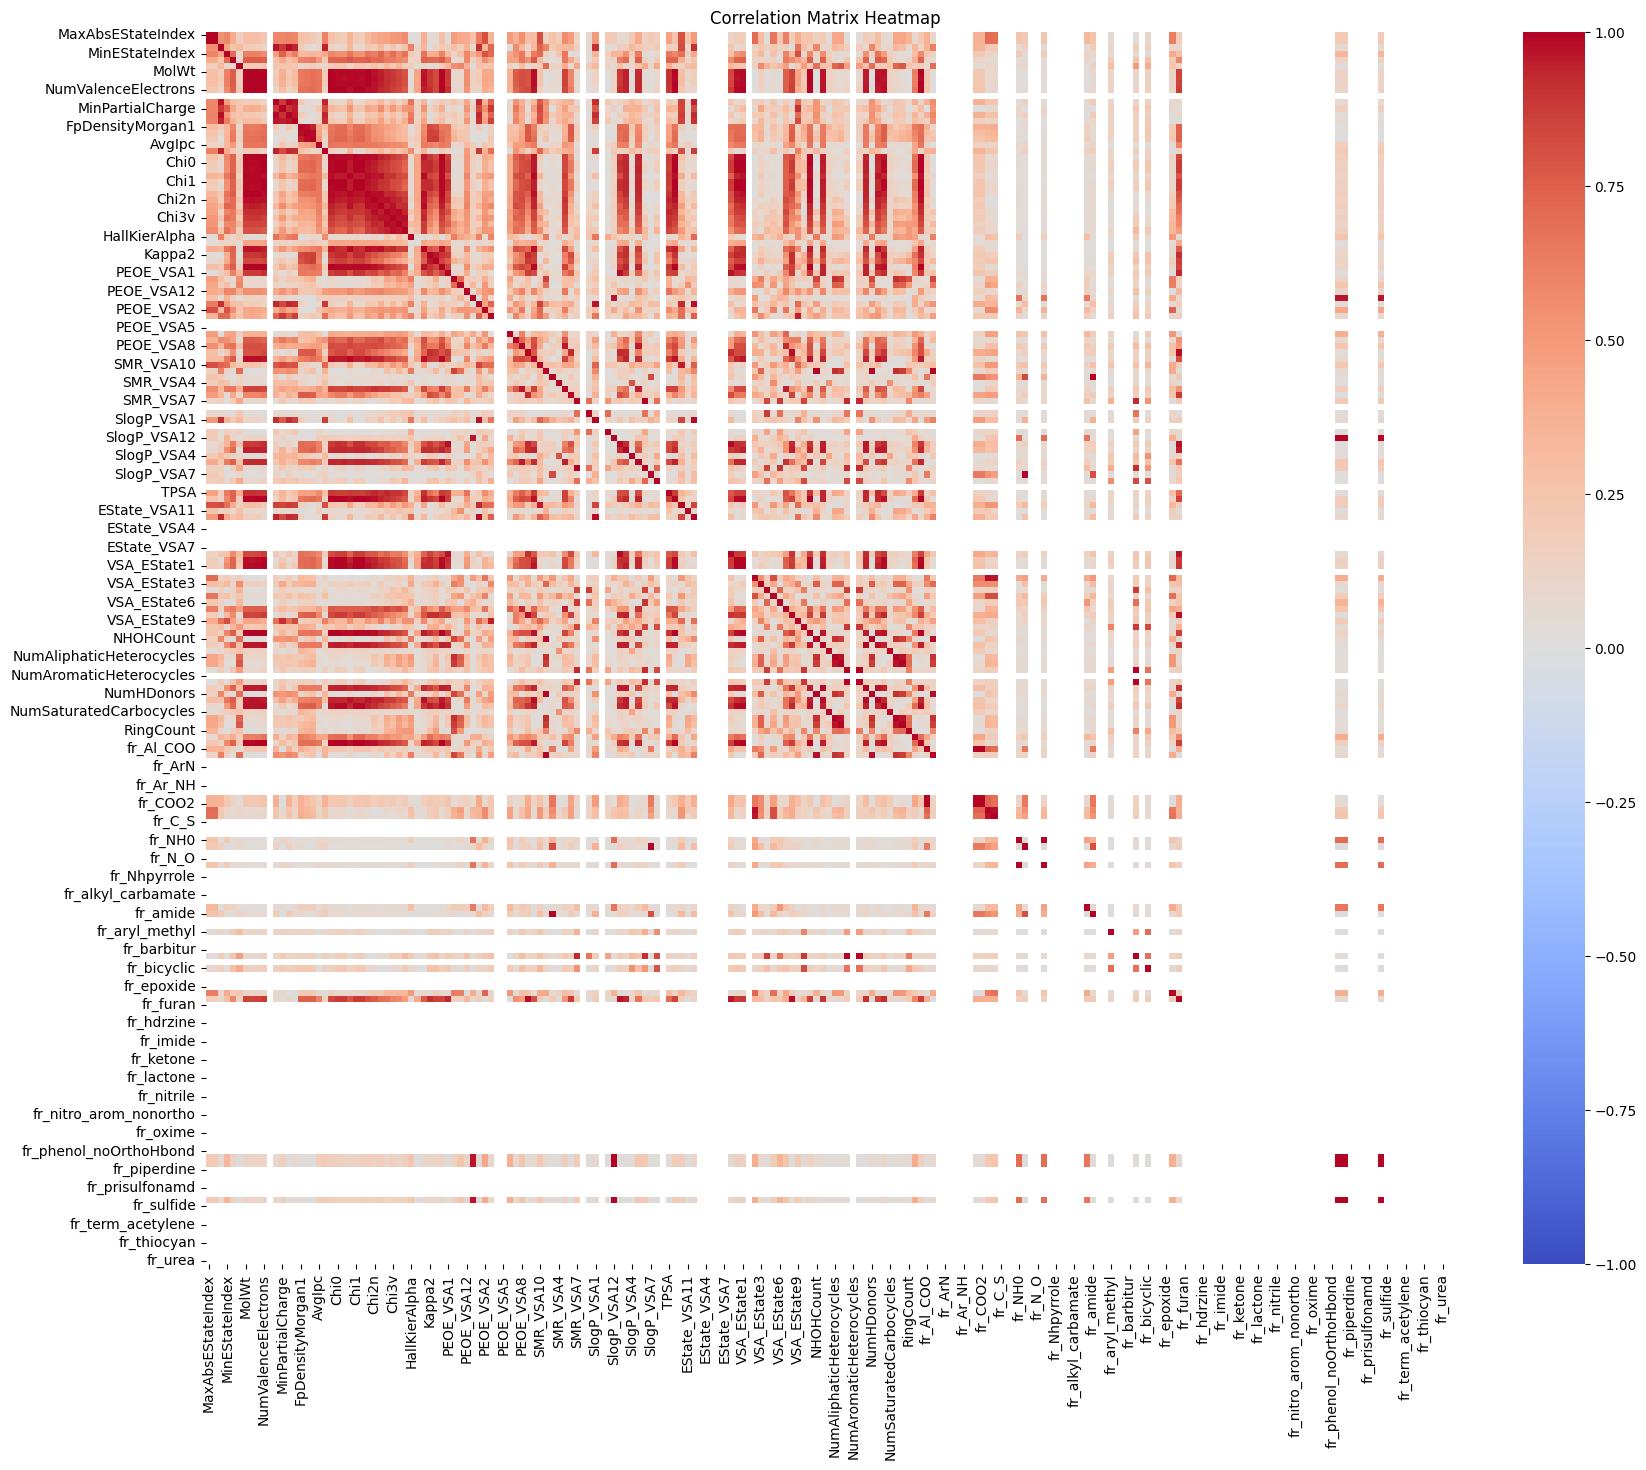

In [ ]:
# Compute the correlation matrix
corr_matrix_full = X_final.corr().abs()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix_full, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()


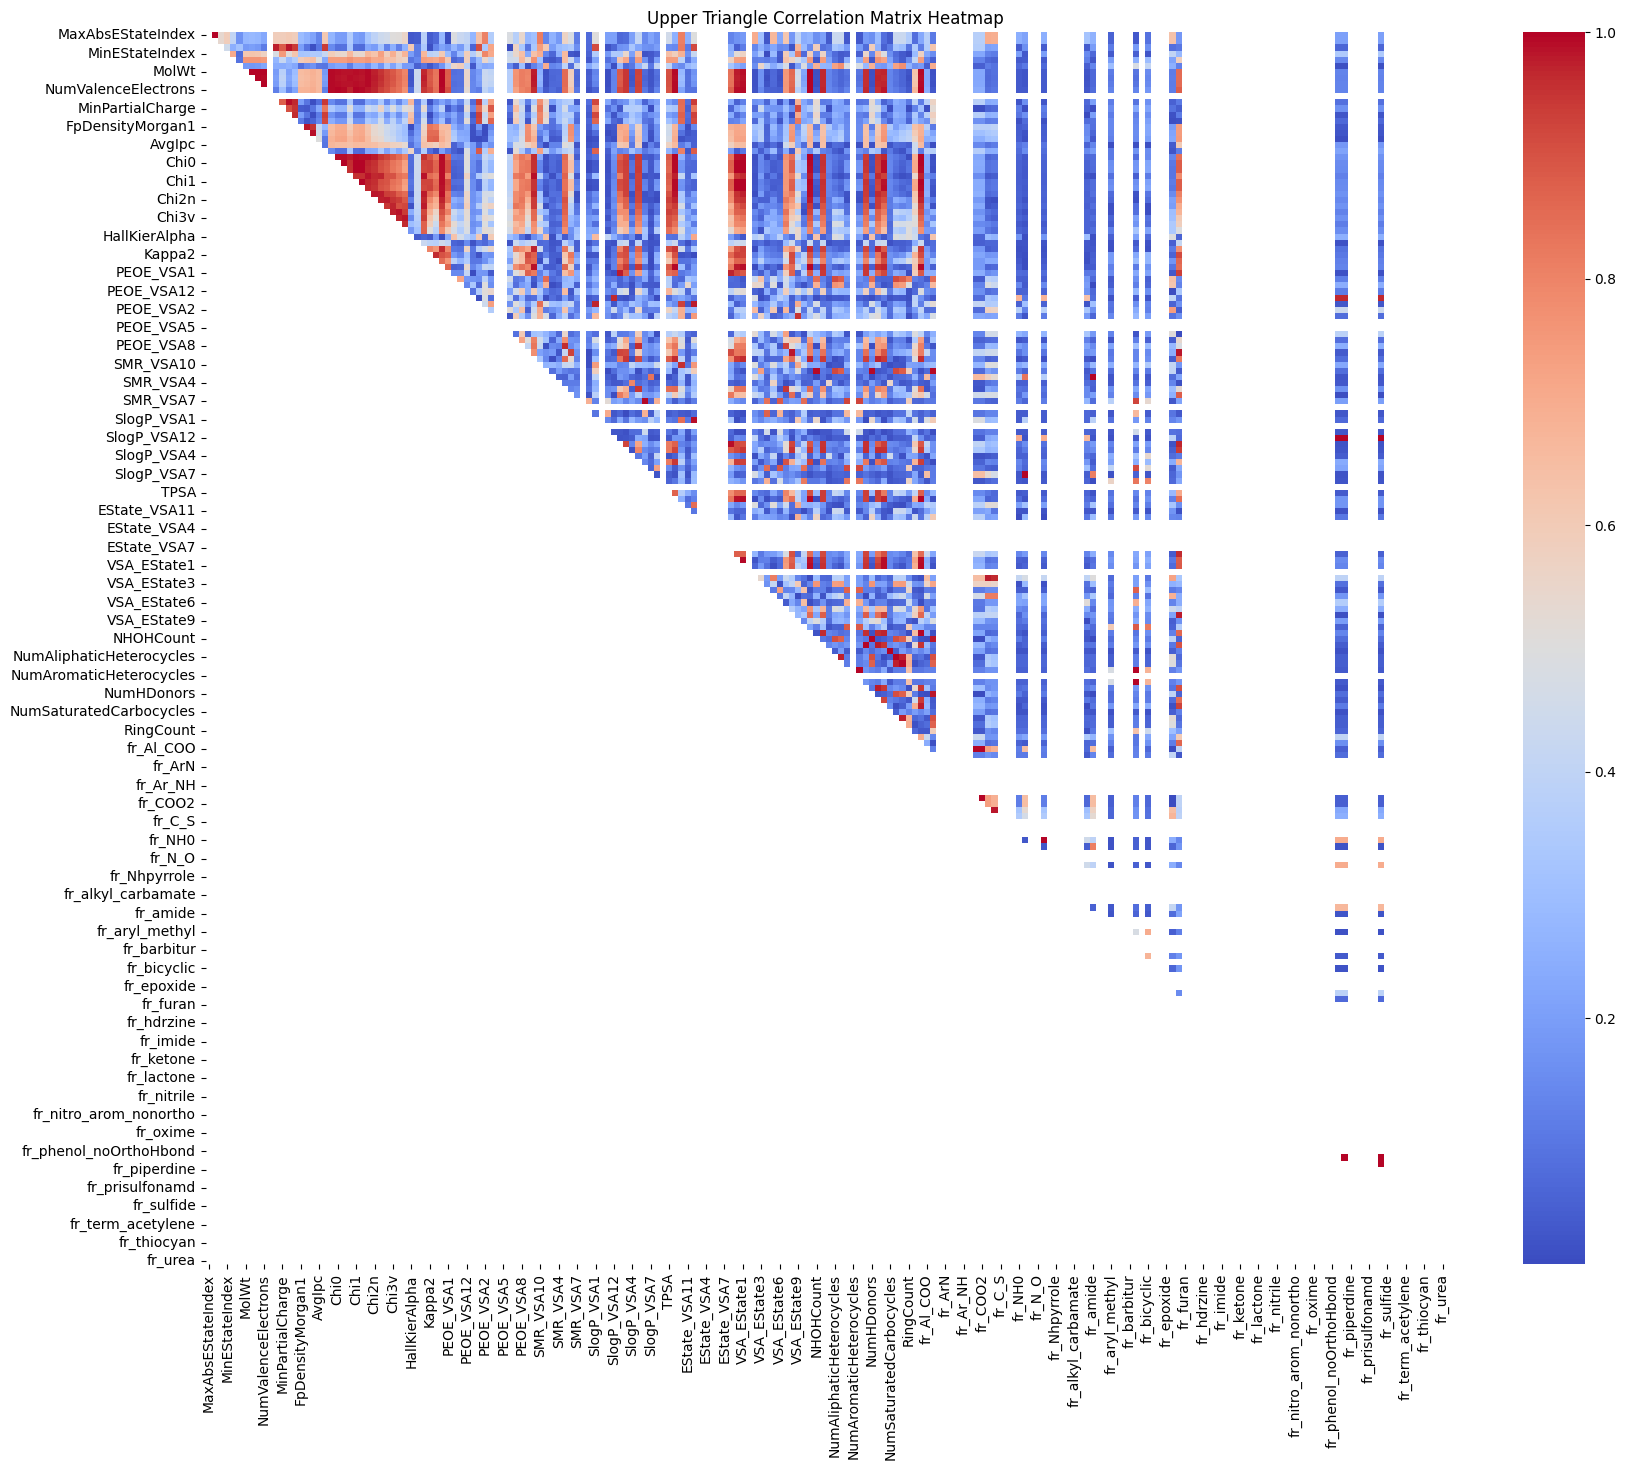

In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(upper, annot=False, cmap='coolwarm')
plt.title('Upper Triangle Correlation Matrix Heatmap')
plt.show()


c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fan_d\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


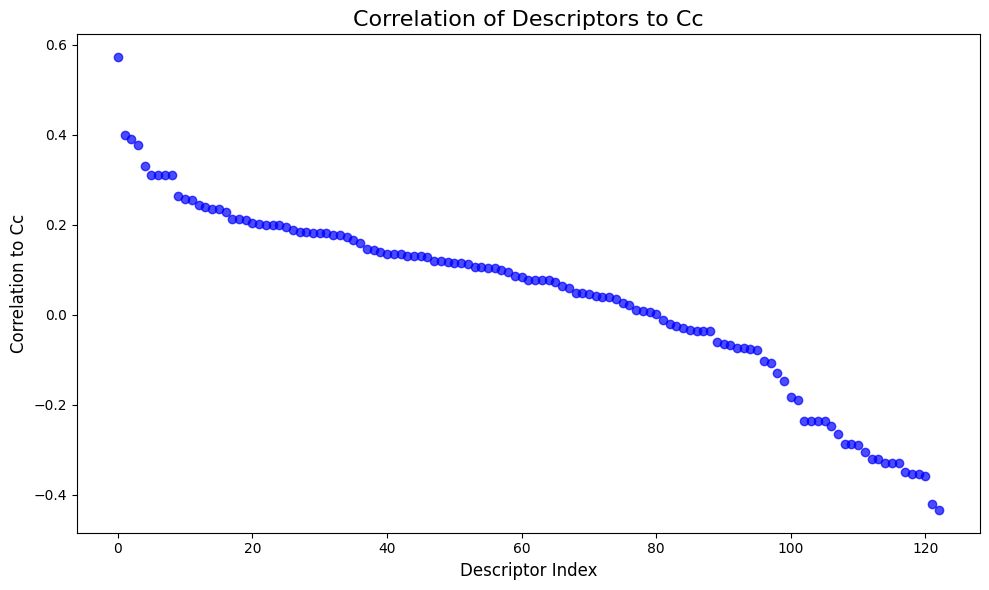

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming X_cleaned_df is your descriptor DataFrame and y_cleaned is your target variable
# Compute the correlations between each descriptor and the target variable
correlations = X_final.corrwith(y)

# Sort the correlations in descending order for clarity
sorted_corr = correlations.sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot of correlation values with the target
plt.scatter(range(len(sorted_corr)), sorted_corr, color='blue', alpha=0.7)

# Add horizontal lines for thresholds (e.g., 0.2 and -0.2)
#plt.axhline(y=0.2, color='red', linestyle='--', linewidth=1.5)  # Upper threshold
#plt.axhline(y=-0.2, color='red', linestyle='--', linewidth=1.5)  # Lower threshold

# Fill the region between thresholds with a light red color
#plt.fill_between(range(len(sorted_corr)), -0.2, 0.2, color='red', alpha=0.1)

# Add labels and title
plt.title(f"Correlation of Descriptors to Cc", fontsize=16)
plt.xlabel("Descriptor Index", fontsize=12)
plt.ylabel("Correlation to Cc", fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
print(f"\nFeatures dropped: {to_drop}")
print(f"Remaining features: {X_reduced.shape[1]}")



Features dropped: ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MaxPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA14', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA5', 'SMR_VSA6', 'SlogP_VSA1', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'MolMR', 'fr_Al_OH', 'fr_COO', 'fr_COO2',

In [ ]:
print(f"Number of samples in X_reduced: {X_reduced.shape[0]}")
print(f"Number of samples in y: {y.shape[0]}")


Number of samples in X_reduced: 84
Number of samples in y: 84


In [ ]:
print(f"Indices in X_reduced: {X_reduced.index}")
print(f"Indices in y: {y.index}")


Indices in X_reduced: RangeIndex(start=0, stop=84, step=1)
Indices in y: RangeIndex(start=0, stop=84, step=1)


In [ ]:
# Assuming X_final is your current feature matrix after imputation and optional dropping
combined_df = pd.concat([X_final, y], axis=1)

print(f"Combined DataFrame shape: {combined_df.shape}")
print(f"Columns: {combined_df.columns.tolist()}")


Combined DataFrame shape: (84, 203)
Columns: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression

# Step 1: Compute the correlation matrix for feature columns only
feature_cols = combined_df.columns.drop(['Cc'])  # Assuming 'Cc' is your target
corr_matrix = combined_df[feature_cols].corr().abs()

# Step 2: Select the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Step 3: Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"\nFeatures to drop due to high correlation: {to_drop}")

# Step 4: Drop the highly correlated features
X_reduced = combined_df.drop(columns=to_drop)

print(f"\nFeature matrix shape after dropping correlated features: {X_reduced.shape}")



Features to drop due to high correlation: ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA5', 'SMR_VSA6', 'SlogP_VSA1', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromati

In [ ]:
# Separate features and target
X_cleaned = X_reduced.drop(['Cc'], axis=1)
y_cleaned = X_reduced['Cc']

print(f"Number of samples in X_cleaned: {X_cleaned.shape[0]}")
print(f"Number of samples in y_cleaned: {y_cleaned.shape[0]}")


Number of samples in X_cleaned: 84
Number of samples in y_cleaned: 84


In [ ]:
y_cleaned

0     2.40
1     0.10
2    -1.60
3     0.80
4    -0.70
      ... 
79   -1.24
80   -2.24
81    0.80
82   -0.20
83   -2.89
Name: Cc, Length: 84, dtype: float64

In [ ]:
# Check for missing values in y_cleaned
print("Missing values in y_cleaned:")
print(y_cleaned.isnull().sum())


Missing values in y_cleaned:
0


In [ ]:
# Identify indices where y_cleaned is NaN
nan_indices = y_cleaned[y_cleaned.isnull()].index
print(f"Indices with NaN in y_cleaned: {nan_indices.tolist()}")


Indices with NaN in y_cleaned: []


In [ ]:
# Check for missing values in y_cleaned
print("Missing values in y_cleaned:")
print(y_cleaned.isnull().sum())


Missing values in y_cleaned:
0


In [ ]:
# Identify indices where y_cleaned is NaN
nan_indices = y_cleaned[y_cleaned.isnull()].index
print(f"Indices with NaN in y_cleaned: {nan_indices.tolist()}")


Indices with NaN in y_cleaned: []


In [ ]:
# Drop samples with NaN in y_cleaned
X_cleaned = X_cleaned.drop(index=nan_indices).reset_index(drop=True)
y_cleaned = y_cleaned.drop(index=nan_indices).reset_index(drop=True)

print(f"Shape of X_cleaned after dropping NaNs: {X_cleaned.shape}")
print(f"Shape of y_cleaned after dropping NaNs: {y_cleaned.shape}")


Shape of X_cleaned after dropping NaNs: (84, 111)
Shape of y_cleaned after dropping NaNs: (84,)


In [ ]:
print(f"Number of samples in X_cleaned: {X_cleaned.shape[0]}")
print(f"Number of samples in y_cleaned: {y_cleaned.shape[0]}")


Number of samples in X_cleaned: 84
Number of samples in y_cleaned: 84


In [ ]:
y_cleaned

0     2.40
1     0.10
2    -1.60
3     0.80
4    -0.70
      ... 
79   -1.24
80   -2.24
81    0.80
82   -0.20
83   -2.89
Name: Cc, Length: 84, dtype: float64

In [ ]:


# Example: Combining original data with descriptors
# Assuming 'df' is your original DataFrame with 'SMILES' and 'Cc'
# 'df_descriptors' is the DataFrame with molecular descriptors

df_cleaned = pd.concat([y_cleaned, X_cleaned], axis=1)

# Display the first few rows to verify
print(df_cleaned.head())
# Define the output file path
output_excel_path_clean = 'descriptors_cleaned.xlsx'

# Save the DataFrame to Excel
df_cleaned.to_excel(output_excel_path_clean, index=False)

print(f"Data successfully saved to {output_excel_path_clean}")


    Cc  MaxAbsEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed  \
0  2.4           7.757794           3.404202       -4.468808  0.531644   
1  0.1           7.823703           3.403794       -4.583189  0.491822   
2 -1.6           7.865362           3.403120       -4.658032  0.434848   
3  0.8           8.240295           3.398471       -5.274636  0.231360   
4 -0.7           8.334186           3.397058       -5.445258  0.123133   

         SPS    MolWt  NumRadicalElectrons  FpDensityMorgan1    AvgIpc  ...  \
0  46.461538  190.283                  0.0          1.153846  2.572963  ...   
1  45.500000  234.336                  0.0          0.937500  2.690666  ...   
2  44.842105  278.389                  0.0          0.789474  2.791876  ...   
3  46.857143  406.604                  0.0          0.535714  3.104562  ...   
4  46.444444  522.764                  0.0          0.416667  0.682523  ...   

   fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term_acetylene  fr_tetrazole  \
0   

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Define the number of top features to select
k = 50  # Adjust based on your dataset size and computational resources

# Initialize SelectKBest
selector = SelectKBest(score_func=f_regression, k=k)

# Fit and transform the data
X_selected = selector.fit_transform(X_cleaned, y_cleaned)

# Get the selected feature names
selected_features = X_cleaned.columns[selector.get_support()].tolist()

print(f"\nSelected Features ({len(selected_features)}):")
print(selected_features)



Selected Features (50):
['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'FpDensityMorgan1', 'AvgIpc', 'HallKierAlpha', 'Ipc', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA6', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA11', 'SlogP_VSA4', 'SlogP_VSA8', 'EState_VSA11', 'VSA_EState2', 'VSA_EState3', 'NumAliphaticCarbocycles', 'MolLogP', 'fr_Al_COO', 'fr_NH0', 'fr_allylic_oxid', 'fr_aryl_methyl', 'fr_ester', 'fr_para_hydroxylation', 'fr_phenol', 'fr_phenol_noOrthoHbond', 'fr_piperdine', 'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea']


C:\Users\fan_d\AppData\Local\Temp\ipykernel_17040\2166904751.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=feature_scores.head(20), palette='viridis')


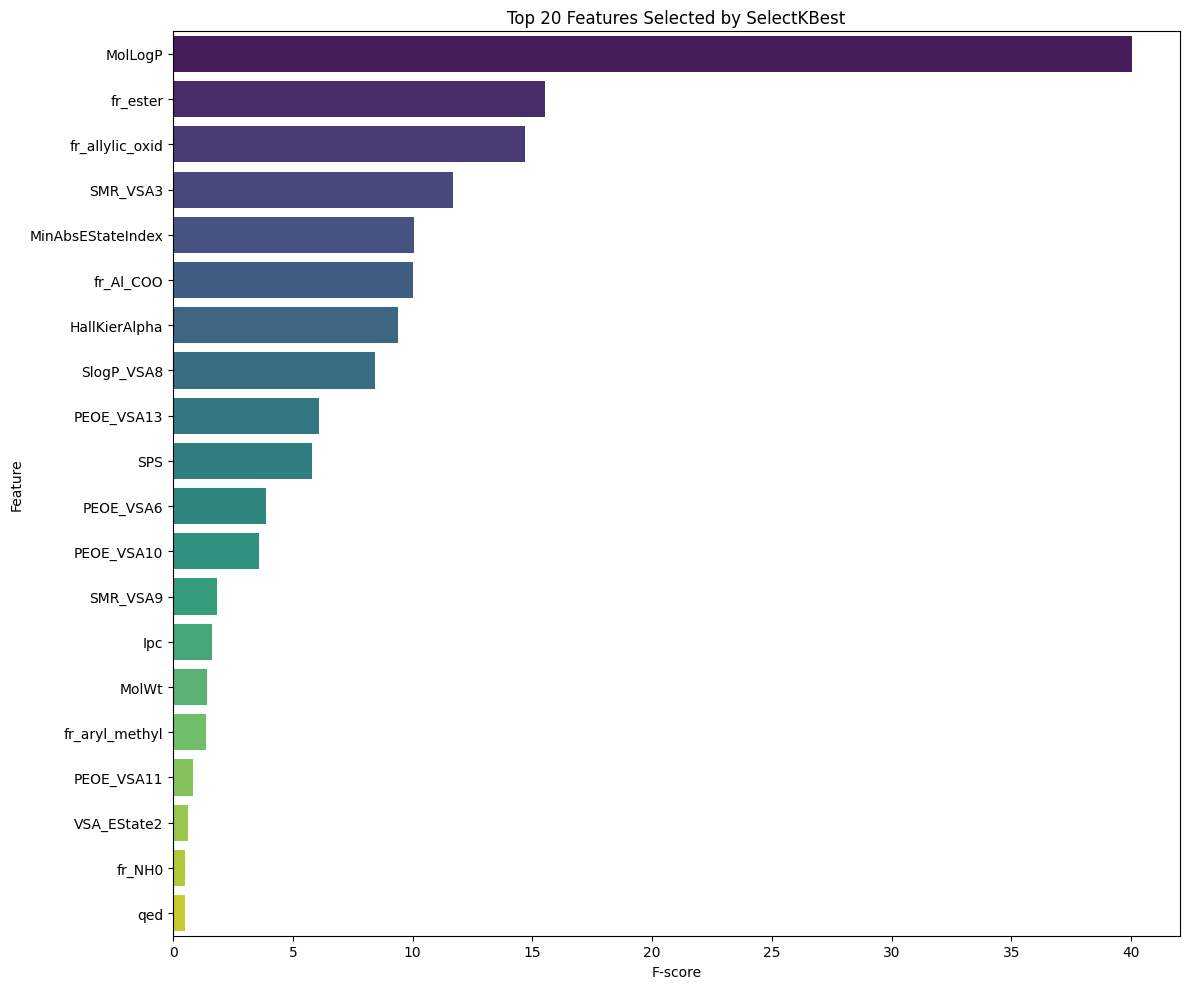

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have computed scores during SelectKBest
scores = selector.scores_

# Create a DataFrame for visualization
feature_scores = pd.DataFrame({
    'Feature': X_cleaned.columns,
    'Score': scores
})

# Sort the features by score
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(20), palette='viridis')
plt.title('Top 20 Features Selected by SelectKBest')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



Selected Features using GradientBoosting (50):
['SMR_VSA8', 'SlogP_VSA10', 'fr_Ndealkylation2', 'EState_VSA11', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'VSA_EState10', 'SlogP_VSA9', 'fr_Imine', 'fr_HOCCN', 'NumAromaticHeterocycles', 'fr_NH2', 'fr_Al_OH_noTert', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_C_S', 'fr_Ar_OH', 'NumAliphaticCarbocycles', 'fr_Al_COO', 'SlogP_VSA4', 'SlogP_VSA11', 'fr_allylic_oxid', 'fr_NH0', 'SMR_VSA9', 'SMR_VSA7', 'SMR_VSA4', 'PEOE_VSA11', 'VSA_EState2', 'MinAbsEStateIndex', 'PEOE_VSA12', 'SlogP_VSA8', 'PEOE_VSA10', 'VSA_EState3', 'SMR_VSA3', 'HallKierAlpha', 'fr_ester', 'AvgIpc', 'PEOE_VSA6', 'MaxAbsEStateIndex', 'qed', 'MinEStateIndex', 'MolWt', 'SPS', 'FpDensityMorgan1', 'MolLogP']


C:\Users\fan_d\AppData\Local\Temp\ipykernel_17040\4082525775.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_scores_gbr.head(20), palette='viridis')


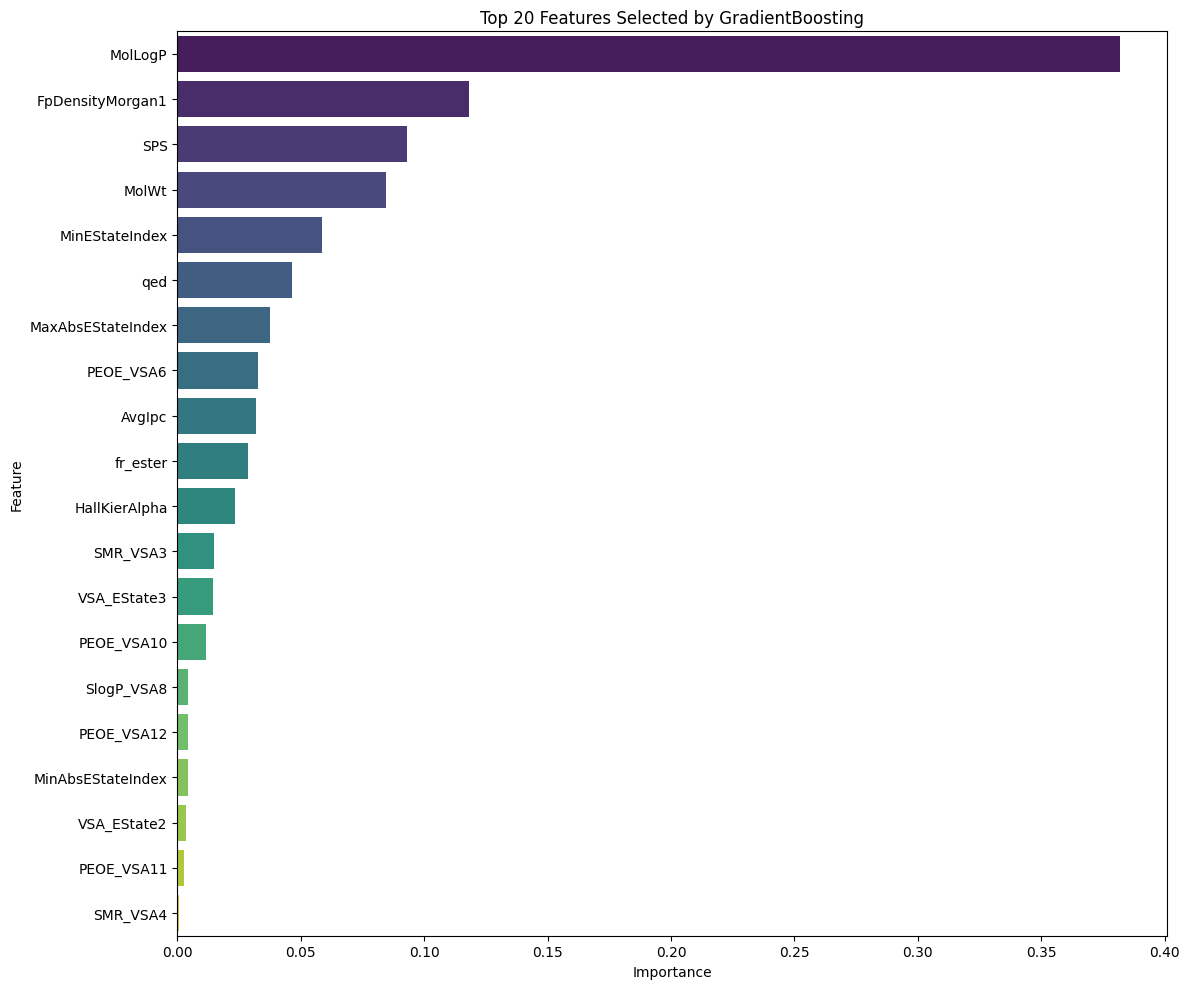

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the GradientBoosting model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
# Fit and transform the data
X_scaled = scaler.fit_transform(X_cleaned)

# Fit the GradientBoosting model after scaling
gbr.fit(X_scaled, y_cleaned)

# Proceed with the rest of your code to get feature importances
importances_gbr = gbr.feature_importances_

# Sort the feature importances and get the top k
indices_gbr = np.argsort(importances_gbr)[-k:]

# Get the selected feature names
selected_features_gbr = X_cleaned.columns[indices_gbr].tolist()

print(f"\nSelected Features using GradientBoosting ({len(selected_features_gbr)}):")
print(selected_features_gbr)

# Create a DataFrame for visualization
feature_scores_gbr = pd.DataFrame({
    'Feature': X_cleaned.columns,
    'Importance': importances_gbr
})

# Sort the features by importance
feature_scores_gbr = feature_scores_gbr.sort_values(by='Importance', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_scores_gbr.head(20), palette='viridis')
plt.title('Top 20 Features Selected by GradientBoosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
X_cleaned

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,FpDensityMorgan1,AvgIpc,HallKierAlpha,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,7.757794,3.404202,-4.468808,0.531644,46.461538,190.283,0.0,1.153846,2.572963,-0.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7.823703,3.403794,-4.583189,0.491822,45.500000,234.336,0.0,0.937500,2.690666,-0.16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7.865362,3.403120,-4.658032,0.434848,44.842105,278.389,0.0,0.789474,2.791876,-0.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8.240295,3.398471,-5.274636,0.231360,46.857143,406.604,0.0,0.535714,3.104562,-0.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8.334186,3.397058,-5.445258,0.123133,46.444444,522.764,0.0,0.416667,0.682523,-0.32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,8.271341,3.397862,-5.331627,0.144736,45.882353,494.710,0.0,0.441176,3.217673,-0.32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80,8.282250,3.397519,-5.351809,0.121876,45.513514,538.763,0.0,0.405405,0.684003,-0.36,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81,8.107304,3.400260,-5.045099,0.298047,45.760000,364.523,0.0,0.600000,3.001337,-0.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
82,8.290589,3.397719,-5.366531,0.164560,46.625000,464.684,0.0,0.468750,3.192272,-0.28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Remove columns where all values are zero
X_zero = X_cleaned.loc[:, (X_cleaned != 0).any(axis=0)]


In [ ]:
X_zero

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,AvgIpc,HallKierAlpha,Ipc,...,EState_VSA11,VSA_EState2,VSA_EState3,NumAliphaticCarbocycles,MolLogP,fr_Al_COO,fr_NH0,fr_allylic_oxid,fr_aryl_methyl,fr_ester
0,7.757794,3.404202,-4.468808,0.531644,46.461538,190.283,1.153846,2.572963,-0.12,2.366300e+06,...,0.0,0.0,3.404202,0.0,1.5922,0.0,0.0,0.0,0.0,0.0
1,7.823703,3.403794,-4.583189,0.491822,45.500000,234.336,0.937500,2.690666,-0.16,3.974684e+07,...,0.0,0.0,3.403794,0.0,1.6088,0.0,0.0,0.0,0.0,0.0
2,7.865362,3.403120,-4.658032,0.434848,44.842105,278.389,0.789474,2.791876,-0.20,6.624386e+08,...,0.0,0.0,3.403120,0.0,1.6254,0.0,0.0,0.0,0.0,0.0
3,8.240295,3.398471,-5.274636,0.231360,46.857143,406.604,0.535714,3.104562,-0.24,1.535786e+13,...,0.0,0.0,3.398471,0.0,3.9826,0.0,0.0,0.0,0.0,0.0
4,8.334186,3.397058,-5.445258,0.123133,46.444444,522.764,0.416667,0.682523,-0.32,1.136013e+23,...,0.0,0.0,3.397058,0.0,4.7960,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,8.271341,3.397862,-5.331627,0.144736,45.882353,494.710,0.441176,3.217673,-0.32,4.106629e+15,...,0.0,0.0,3.397862,0.0,4.0158,0.0,0.0,0.0,0.0,0.0
80,8.282250,3.397519,-5.351809,0.121876,45.513514,538.763,0.405405,0.684003,-0.36,7.429606e+22,...,0.0,0.0,3.397519,0.0,4.0324,0.0,0.0,0.0,0.0,0.0
81,8.107304,3.400260,-5.045099,0.298047,45.760000,364.523,0.600000,3.001337,-0.24,4.121051e+11,...,0.0,0.0,3.400260,0.0,2.8123,0.0,0.0,0.0,0.0,0.0
82,8.290589,3.397719,-5.366531,0.164560,46.625000,464.684,0.468750,3.192272,-0.28,8.377531e+14,...,0.0,0.0,3.397719,0.0,4.3893,0.0,0.0,0.0,0.0,0.0



Selected Features using GradientBoosting (32):
['SlogP_VSA11', 'EState_VSA11', 'NumAliphaticCarbocycles', 'fr_aryl_methyl', 'SMR_VSA9', 'SlogP_VSA4', 'fr_NH0', 'fr_Al_COO', 'SMR_VSA4', 'MinAbsEStateIndex', 'PEOE_VSA12', 'PEOE_VSA11', 'Ipc', 'PEOE_VSA10', 'PEOE_VSA13', 'SlogP_VSA8', 'SMR_VSA7', 'AvgIpc', 'MinEStateIndex', 'VSA_EState3', 'fr_ester', 'SMR_VSA3', 'VSA_EState2', 'PEOE_VSA6', 'FpDensityMorgan1', 'HallKierAlpha', 'fr_allylic_oxid', 'MolWt', 'MaxAbsEStateIndex', 'qed', 'SPS', 'MolLogP']


C:\Users\fan_d\AppData\Local\Temp\ipykernel_17040\2132507377.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_scores_gbr.head(20), palette='viridis')


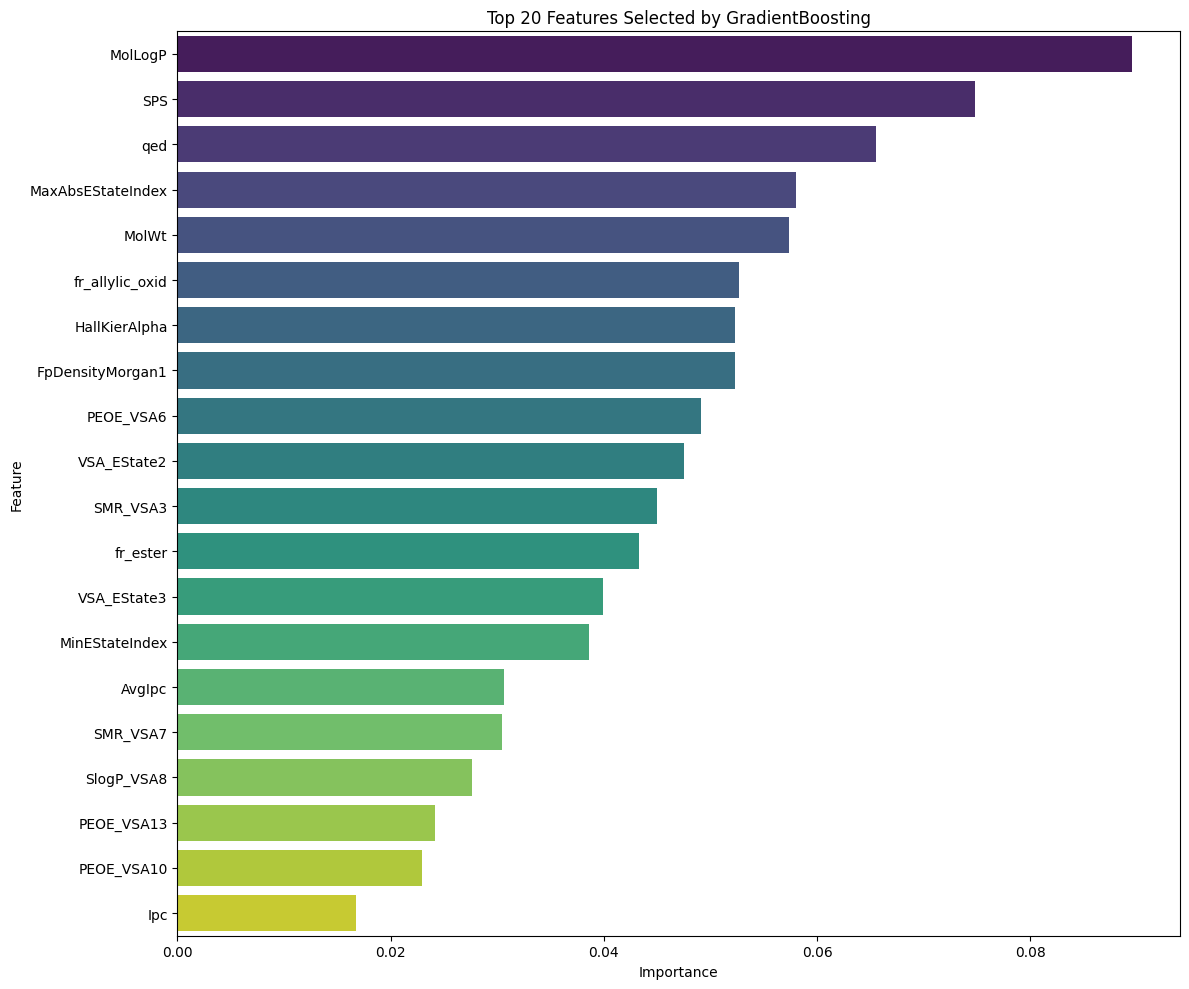

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the GradientBoosting model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42, max_features=1)
# Fit and transform the data
X_scaled = scaler.fit_transform(X_zero)

# Fit the GradientBoosting model after scaling
gbr.fit(X_scaled, y_cleaned)

# Proceed with the rest of your code to get feature importances
importances_gbr = gbr.feature_importances_

# Sort the feature importances and get the top k
indices_gbr = np.argsort(importances_gbr)[-k:]

# Get the selected feature names
selected_features_gbr = X_zero.columns[indices_gbr].tolist()

print(f"\nSelected Features using GradientBoosting ({len(selected_features_gbr)}):")
print(selected_features_gbr)

# Create a DataFrame for visualization
feature_scores_gbr = pd.DataFrame({
    'Feature': X_zero.columns,
    'Importance': importances_gbr
})

# Sort the features by importance
feature_scores_gbr = feature_scores_gbr.sort_values(by='Importance', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_scores_gbr.head(20), palette='viridis')
plt.title('Top 20 Features Selected by GradientBoosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


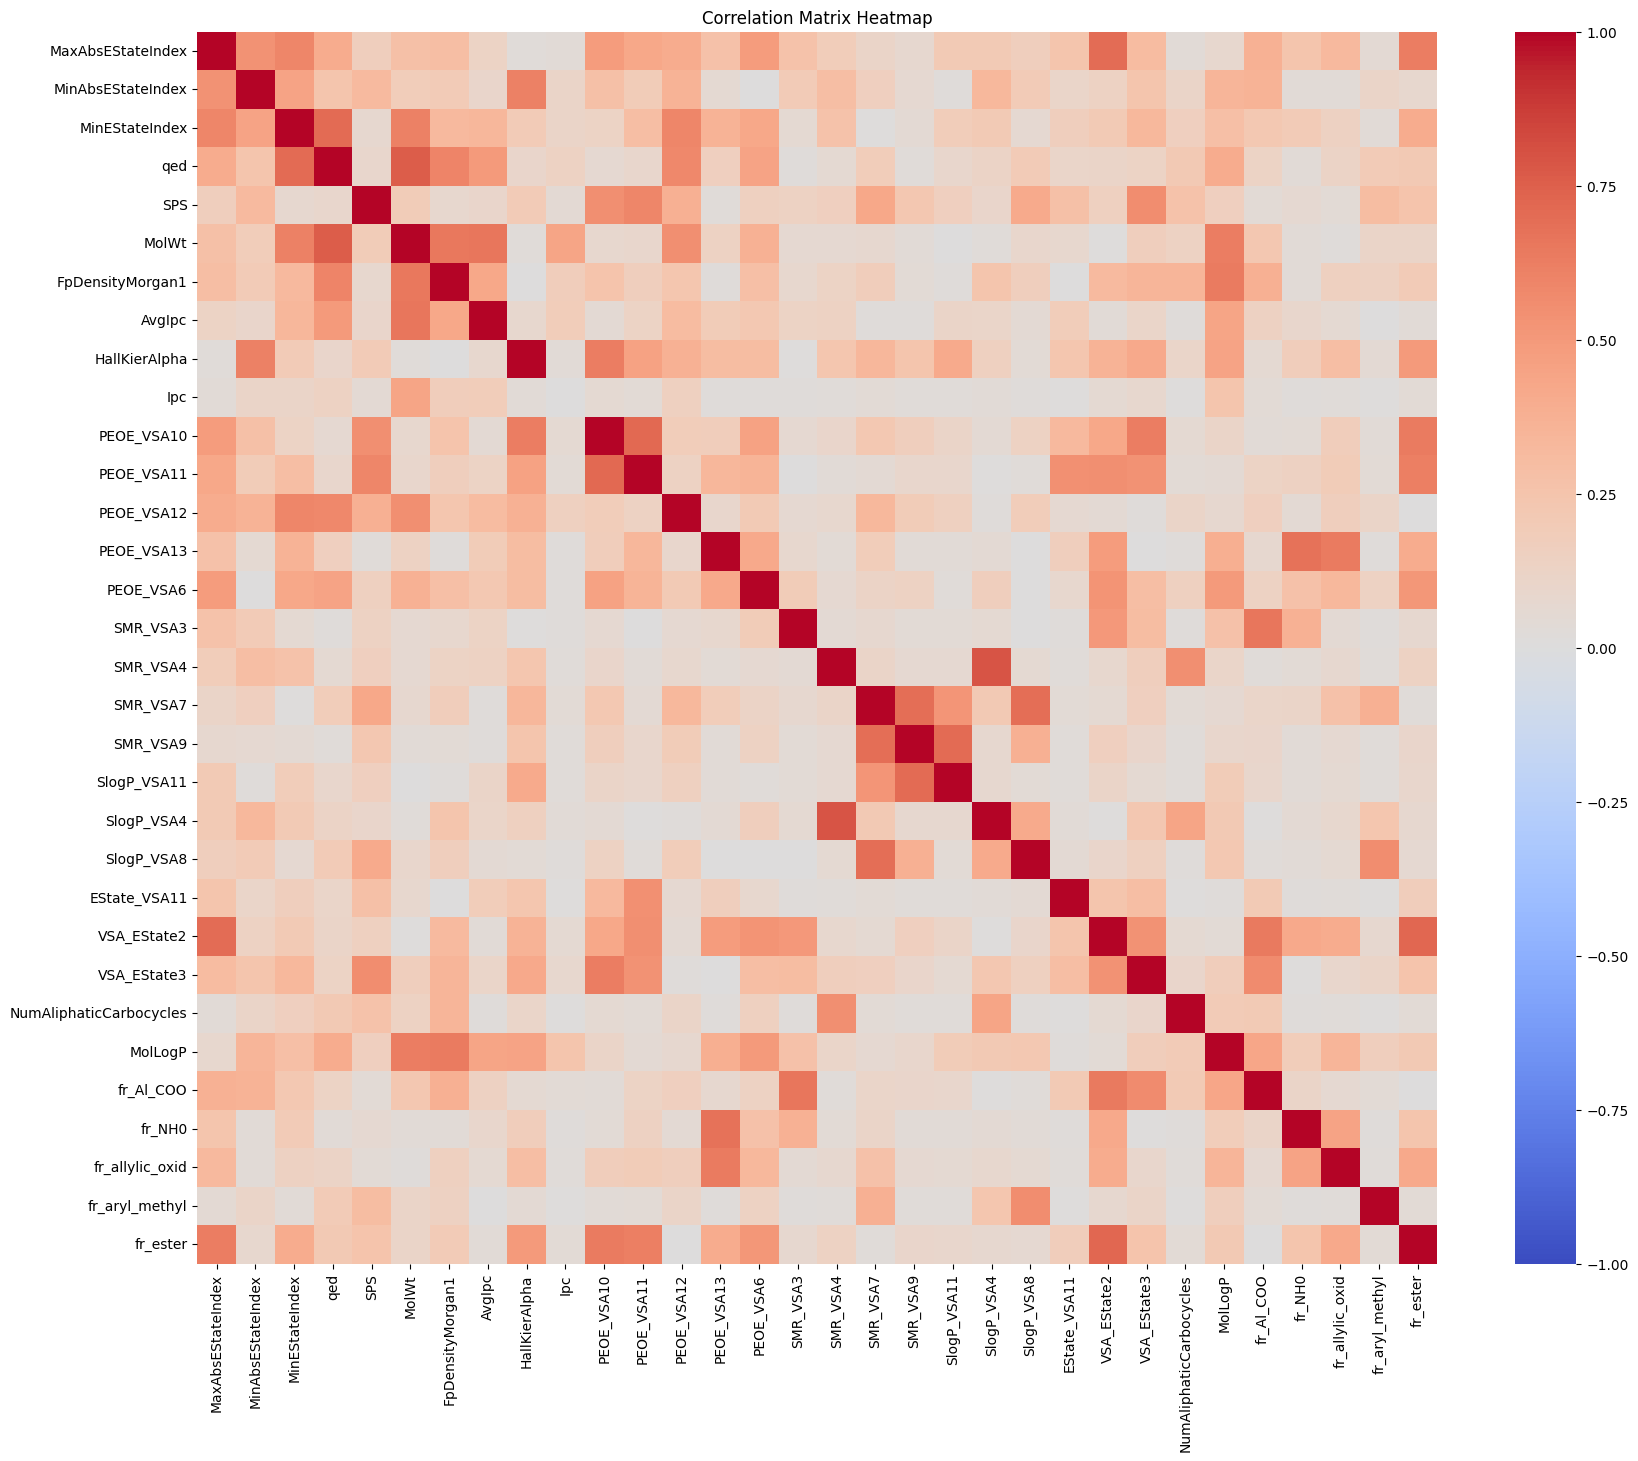

In [ ]:
# Compute the correlation matrix
corr_matrix_full = X_zero.corr().abs()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix_full, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()



Selected Features using GradientBoosting (50):
['EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'VSA_EState10', 'NumAromaticHeterocycles', 'SlogP_VSA9', 'fr_Imine', 'fr_Al_OH_noTert', 'fr_HOCCN', 'fr_NH2', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_C_S', 'SlogP_VSA11', 'Ipc', 'NumAliphaticCarbocycles', 'fr_aryl_methyl', 'EState_VSA11', 'SlogP_VSA4', 'SMR_VSA4', 'SlogP_VSA8', 'SMR_VSA9', 'fr_NH0', 'PEOE_VSA12', 'MinAbsEStateIndex', 'PEOE_VSA6', 'PEOE_VSA13', 'AvgIpc', 'PEOE_VSA11', 'SMR_VSA3', 'HallKierAlpha', 'fr_ester', 'FpDensityMorgan1', 'PEOE_VSA10', 'SMR_VSA7', 'VSA_EState3', 'VSA_EState2', 'fr_allylic_oxid', 'fr_Al_COO', 'MolLogP', 'MaxAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'qed']


C:\Users\fan_d\AppData\Local\Temp\ipykernel_17040\1223729556.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_scores_gbr.head(20), palette='viridis')


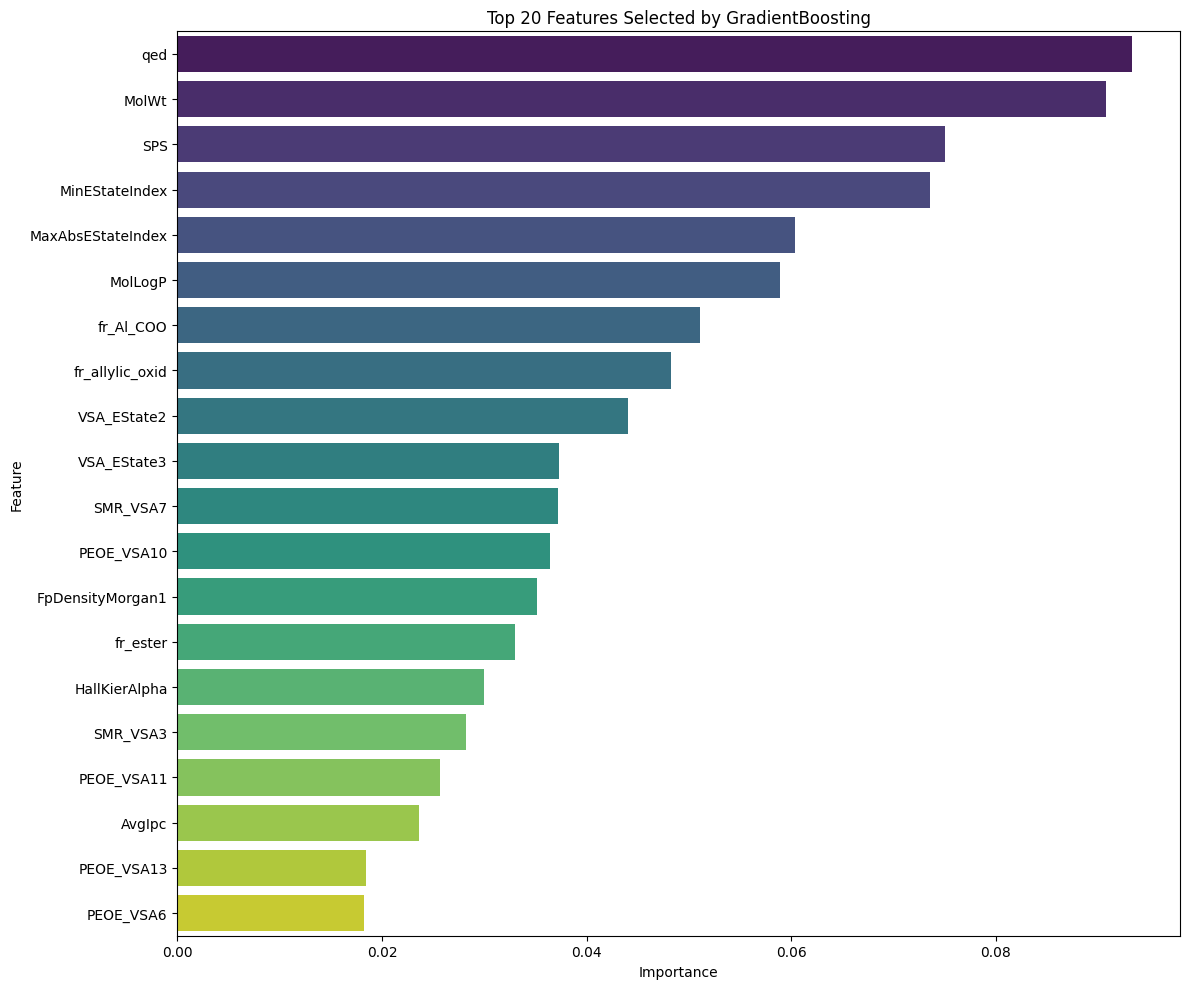

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X_cleaned)

# Fit the GradientBoosting model after scaling
gbr.fit(X_scaled, y_cleaned)

# Proceed with the rest of your code to get feature importances
importances_gbr = gbr.feature_importances_

# Sort the feature importances and get the top k
indices_gbr = np.argsort(importances_gbr)[-k:]

# Get the selected feature names
selected_features_gbr = X_cleaned.columns[indices_gbr].tolist()

print(f"\nSelected Features using GradientBoosting ({len(selected_features_gbr)}):")
print(selected_features_gbr)

# Create a DataFrame for visualization
feature_scores_gbr = pd.DataFrame({
    'Feature': X_cleaned.columns,
    'Importance': importances_gbr
})

# Sort the features by importance
feature_scores_gbr = feature_scores_gbr.sort_values(by='Importance', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_scores_gbr.head(20), palette='viridis')
plt.title('Top 20 Features Selected by GradientBoosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
feature_scores_gbr

,Feature,Importance
3,qed,0.093343
5,MolWt,0.090763
4,SPS,0.075006
2,MinEStateIndex,0.073589
0,MaxAbsEStateIndex,0.060352
...,...,...
52,fr_N_O,0.000000
51,fr_NH2,0.000000
49,fr_Imine,0.000000
48,fr_HOCCN,0.000000


In [ ]:
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Clean up infinity and NaN values
X_cleaned = X_cleaned.replace([np.inf, -np.inf], np.nan)
X_cleaned = X_cleaned.fillna(X_cleaned.mean())

# Clip large values to avoid overflow
X_cleaned = X_cleaned.clip(-1e5, 1e5)

# Scale the features if necessary
scaler = StandardScaler()
X_cleaned_scaled = scaler.fit_transform(X_cleaned)

# Initialize the Gradient Boosting model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42, max_features=1)

# Initialize RFE and select the number of features to keep
rfe = RFE(estimator=gbr, n_features_to_select=10)

# Fit RFE with the cleaned and scaled data
rfe.fit(X_cleaned_scaled, y_cleaned)

# Get the selected features
selected_features_rfe = X_cleaned.columns[rfe.support_].tolist()

print(f"Selected Features after RFE: {selected_features_rfe}")
# Create a new DataFrame that includes only the selected features
X_selected_df = X_cleaned[selected_features_rfe]

# Display the new DataFrame
print(X_selected_df.head())

Selected Features after RFE: ['MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'AvgIpc', 'PEOE_VSA6', 'VSA_EState3', 'MolLogP', 'fr_ester']
   MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt    AvgIpc  \
0           3.404202       -4.468808  0.531644  46.461538  190.283  2.572963   
1           3.403794       -4.583189  0.491822  45.500000  234.336  2.690666   
2           3.403120       -4.658032  0.434848  44.842105  278.389  2.791876   
3           3.398471       -5.274636  0.231360  46.857143  406.604  3.104562   
4           3.397058       -5.445258  0.123133  46.444444  522.764  0.682523   

   PEOE_VSA6  VSA_EState3  MolLogP  fr_ester  
0  25.970667     3.404202   1.5922       0.0  
1  25.970667     3.403794   1.6088       0.0  
2  25.970667     3.403120   1.6254       0.0  
3  64.208216     3.398471   3.9826       0.0  
4  76.954066     3.397058   4.7960       0.0  


In [ ]:


# Example: Combining original data with descriptors
# Assuming 'df' is your original DataFrame with 'SMILES' and 'Cc'
# 'df_descriptors' is the DataFrame with molecular descriptors

df_rfe = pd.concat([y_cleaned, X_selected_df], axis=1)

# Display the first few rows to verify
print(df_rfe.head())
# Define the output file path
output_excel_path_rfe = 'RFE_data.xlsx'

# Save the DataFrame to Excel
df_rfe.to_excel(output_excel_path_rfe, index=False)

print(f"Data successfully saved to {output_excel_path_rfe}")


    Cc  MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  \
0  2.4           3.404202       -4.468808  0.531644  46.461538  190.283   
1  0.1           3.403794       -4.583189  0.491822  45.500000  234.336   
2 -1.6           3.403120       -4.658032  0.434848  44.842105  278.389   
3  0.8           3.398471       -5.274636  0.231360  46.857143  406.604   
4 -0.7           3.397058       -5.445258  0.123133  46.444444  522.764   

     AvgIpc  PEOE_VSA6  VSA_EState3  MolLogP  fr_ester  
0  2.572963  25.970667     3.404202   1.5922       0.0  
1  2.690666  25.970667     3.403794   1.6088       0.0  
2  2.791876  25.970667     3.403120   1.6254       0.0  
3  3.104562  64.208216     3.398471   3.9826       0.0  
4  0.682523  76.954066     3.397058   4.7960       0.0  
Data successfully saved to RFE_data.xlsx


In [ ]:
# Load the saved Excel to verify
df_RFE_load= pd.read_excel('RFE_data.xlsx')
print(df_RFE_load.head())
print(df_RFE_load.info())

    Cc  MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  \
0  2.4           3.404202       -4.468808  0.531644  46.461538  190.283   
1  0.1           3.403794       -4.583189  0.491822  45.500000  234.336   
2 -1.6           3.403120       -4.658032  0.434848  44.842105  278.389   
3  0.8           3.398471       -5.274636  0.231360  46.857143  406.604   
4 -0.7           3.397058       -5.445258  0.123133  46.444444  522.764   

     AvgIpc  PEOE_VSA6  VSA_EState3  MolLogP  fr_ester  
0  2.572963  25.970667     3.404202   1.5922         0  
1  2.690666  25.970667     3.403794   1.6088         0  
2  2.791876  25.970667     3.403120   1.6254         0  
3  3.104562  64.208216     3.398471   3.9826         0  
4  0.682523  76.954066     3.397058   4.7960         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cc 

In [ ]:
df_RFE_load

,Cc,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,AvgIpc,PEOE_VSA6,VSA_EState3,MolLogP,fr_ester
0,2.40,3.404202,-4.468808,0.531644,46.461538,190.283,2.572963,25.970667,3.404202,1.5922,0
1,0.10,3.403794,-4.583189,0.491822,45.500000,234.336,2.690666,25.970667,3.403794,1.6088,0
2,-1.60,3.403120,-4.658032,0.434848,44.842105,278.389,2.791876,25.970667,3.403120,1.6254,0
3,0.80,3.398471,-5.274636,0.231360,46.857143,406.604,3.104562,64.208216,3.398471,3.9826,0
4,-0.70,3.397058,-5.445258,0.123133,46.444444,522.764,0.682523,76.954066,3.397058,4.7960,0
...,...,...,...,...,...,...,...,...,...,...,...
79,-1.24,3.397862,-5.331627,0.144736,45.882353,494.710,3.217673,64.208216,3.397862,4.0158,0
80,-2.24,3.397519,-5.351809,0.121876,45.513514,538.763,0.684003,64.208216,3.397519,4.0324,0
81,0.80,3.400260,-5.045099,0.298047,45.760000,364.523,3.001337,45.089442,3.400260,2.8123,0
82,-0.20,3.397719,-5.366531,0.164560,46.625000,464.684,3.192272,70.581141,3.397719,4.3893,0


In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Clean up infinity and NaN values
X_cleaned = X_cleaned.replace([np.inf, -np.inf], np.nan)
X_cleaned = X_cleaned.fillna(X_cleaned.mean())

# Clip large values to avoid overflow
X_cleaned = X_cleaned.clip(-1e5, 1e5)

# Scale the features if necessary
scaler = StandardScaler()
X_cleaned_scaled = scaler.fit_transform(X_cleaned)

# Initialize the Gradient Boosting model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42,max_features=1)

# Initialize RFE and select the number of features to keep
rfe = RFE(estimator=gbr, n_features_to_select=10)

# Fit RFE with the cleaned and scaled data
rfe.fit(X_cleaned_scaled, y_cleaned)

# Get the selected features
selected_features_rfe = X_cleaned.columns[rfe.support_].tolist()
print(f"Selected Features after RFE: {selected_features_rfe}")

# Create a new DataFrame that includes only the selected features
X_selected_df = X_cleaned[selected_features_rfe]

# Set up Leave-One-Out Cross-Validation (LOOCV)
loo = LeaveOneOut()

# Perform LOOCV with cross_val_score
cv_scores = cross_val_score(gbr, X_selected_df, y_cleaned, cv=loo, scoring='neg_mean_squared_error')

# Convert negative mean squared error to positive values (since cross_val_score returns negative MSE)
cv_scores = np.abs(cv_scores)

print(f"LOOCV MSE Scores: {cv_scores}")
print(f"Average MSE across all samples: {np.mean(cv_scores)}")


Selected Features after RFE: ['MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'AvgIpc', 'PEOE_VSA6', 'VSA_EState3', 'MolLogP', 'fr_ester']
LOOCV MSE Scores: [5.15722404e+00 7.22077006e-01 1.93865067e+00 3.96835887e-02
 4.23022316e+00 3.23306650e+00 9.85120921e-02 7.23583977e-01
 2.13612537e-02 2.10604238e+01 2.94149698e+00 3.82961122e-02
 3.96071223e-02 5.96454591e+00 2.09769950e+00 1.04388983e+00
 1.03870061e-01 5.50357057e-01 8.32843820e-02 9.36583428e-02
 1.50381579e-01 8.98047417e-02 1.20899771e-01 3.11543151e-01
 2.81928125e-01 1.26776247e-01 1.70060903e-02 1.05333329e-01
 4.53062679e-03 3.64711629e-05 1.37619636e-02 4.71240709e-01
 4.56280334e+00 8.26583916e-03 1.47173033e+01 4.41705901e-02
 1.33876853e+00 7.85101574e-02 1.22130416e+00 4.84773426e-01
 6.52409844e+00 1.38843517e-01 2.55183744e+00 1.88246730e+00
 2.87445723e-02 1.35043794e+00 1.35019851e+00 1.26471597e-01
 5.68456313e-01 1.19479834e+00 2.90268476e+01 8.90706727e+00
 3.26727980e-01 6.10958577e+00 4.346

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Clean up infinity and NaN values
X_cleaned = X_cleaned.replace([np.inf, -np.inf], np.nan)
X_cleaned = X_cleaned.fillna(X_cleaned.mean())

# Clip large values to avoid overflow
X_cleaned = X_cleaned.clip(-1e5, 1e5)

# Scale the features if necessary
scaler = StandardScaler()
X_cleaned_scaled = scaler.fit_transform(X_cleaned)

# Initialize the Gradient Boosting model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Initialize RFE and select the number of features to keep
rfe = RFE(estimator=gbr, n_features_to_select=10)

# Fit RFE with the cleaned and scaled data
rfe.fit(X_cleaned_scaled, y_cleaned)

# Get the selected features
selected_features_rfe = X_cleaned.columns[rfe.support_].tolist()
print(f"Selected Features after RFE: {selected_features_rfe}")

# Create a new DataFrame that includes only the selected features
X_selected_df = X_cleaned[selected_features_rfe]

# Perform cross-validation
cv_scores = cross_val_score(gbr, X_selected_df, y_cleaned, cv=5, scoring='neg_mean_squared_error')

# Convert negative mean squared error to positive values (since cross_val_score returns negative MSE)
cv_scores = np.abs(cv_scores)

print(f"Cross-Validation MSE Scores: {cv_scores}")
print(f"Average MSE across folds: {np.mean(cv_scores)}")


Selected Features after RFE: ['MaxAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'FpDensityMorgan1', 'AvgIpc', 'PEOE_VSA6', 'MolLogP', 'fr_ester']
Cross-Validation MSE Scores: [2.33589493 1.63481241 3.00467279 9.48482668 1.17158359]
Average MSE across folds: 3.526358081491396


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load the Breast Cancer Wisconsin dataset
data = pd.read_excel('RFE_data.xlsx')
X = data.drop('Cc', axis=1)  # Features (all columns except the target)
y = data['Cc']  # Target column (what you are predicting)



# Data Cleaning
# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Data Exploration
print("\nBasic statistics of the dataset:")
print(data.describe())



# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





# 7. Decision Tree Regression
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Performance
print("\nDecision Tree Regression:")
print("Training set score: {:.2f}".format(tree_model.score(X_train, y_train)))
print("Test set score: {:.2f}".format(tree_model.score(X_test, y_test)))
print("MSE:", mean_squared_error(y_test, y_pred_tree))
print("R^2:", r2_score(y_test, y_pred_tree))

# 8. Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Performance
print("\nRandom Forest Regression:")
print("Training set score: {:.2f}".format(rf_model.score(X_train, y_train)))
print("Test set score: {:.2f}".format(rf_model.score(X_test, y_test)))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R^2:", r2_score(y_test, y_pred_rf))

# 9. Gradient Boosting Regression
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Performance
print("\nGradient Boosting Regression:")
print("Training set score: {:.2f}".format(gb_model.score(X_train, y_train)))
print("Test set score: {:.2f}".format(gb_model.score(X_test, y_test)))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("R^2:", r2_score(y_test, y_pred_gb))

# Summary of performances
results = {
    "Model": [
              "Decision Tree Regression", "Random Forest Regression", "Gradient Boosting Regression"],
    "MSE": [mean_squared_error(y_test, y_pred_tree),
            mean_squared_error(y_test, y_pred_rf),
            mean_squared_error(y_test, y_pred_gb)],
    "R^2": [r2_score(y_test, y_pred_tree),
            r2_score(y_test, y_pred_rf),
            r2_score(y_test, y_pred_gb)],
}

results_df = pd.DataFrame(results)
print("\nSummary of Model Performances:")
print(results_df)



Missing values in each column:
Cc                   0
MinAbsEStateIndex    0
MinEStateIndex       0
qed                  0
SPS                  0
MolWt                0
AvgIpc               0
PEOE_VSA6            0
VSA_EState3          0
MolLogP              0
fr_ester             0
dtype: int64

Basic statistics of the dataset:
              Cc  MinAbsEStateIndex  MinEStateIndex        qed        SPS  \
count  84.000000          84.000000       84.000000  84.000000  84.000000   
mean   -0.871583           1.680731       -5.661190   0.213761  48.326318   
std     2.261357           1.653167        0.843060   0.149171  10.543059   
min    -5.700000           0.000000       -8.332973   0.020117  19.937500   
25%    -2.225000           0.000000       -6.451551   0.087697  44.031505   
50%    -1.220000           1.895109       -5.359170   0.172258  46.490028   
75%     0.270000           3.399061       -5.053155   0.321817  50.531429   
max     6.600000           3.620359       -3.975463  

In [ ]:
#### Mordreed library ####

In [ ]:
# Define feature matrix X and target vector y
X_mordreed = df_loaded_mordreed.drop(['Cc'], axis=1)  # Features include SMILES and descriptors
y_mordreed = df_loaded_mordreed['Cc']  # Target variable

# Display the first few rows
print(X.head())
print(y.head())


In [ ]:
# Identify numeric columns
numeric_cols_mordreed = X_mordreed.select_dtypes(include=['number']).columns.tolist()

# Identify non-numeric columns
non_numeric_cols_mordreed = X_mordreed.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric Columns: {numeric_cols_mordreed}")
print(f"Non-Numeric Columns: {non_numeric_cols_mordreed}")


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer_mordreed = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns
X_numeric_mordreed = X_mordreed[numeric_cols_mordreed]
X_numeric_imputed_mordreed = pd.DataFrame(imputer.fit_transform(X_numeric_mordreed), columns=numeric_cols_mordreed)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed_mordreed = pd.concat([X_mordreed[non_numeric_cols_mordreed], X_numeric_imputed_mordreed], axis=1)

# Verify that there are no missing values
print("Missing values after imputation:")
print(X_imputed_mordreed.isnull().sum())


In [ ]:
# Check the data types of the numeric columns
print("Data Types of Numeric Columns:")
print(X_numeric_mordreed.dtypes)


In [ ]:
# Identify non-numeric columns in numeric_cols
non_numeric_in_numeric_mordreed = X_numeric_mordreed.select_dtypes(exclude=['number']).columns.tolist()

print(f"Non-Numeric Columns in Numeric Features: {non_numeric_in_numeric_mordreed}")


In [ ]:
# Attempt to convert non-numeric columns to numeric, coercing errors to NaN
for col_mordreed in non_numeric_in_numeric_mordreed:
    X_numeric_mordreed[col_mordreed] = pd.to_numeric(X_numeric_mordreed[col_mordreed], errors='coerce')
    print(f"Converted column '{col_mordreed}' to numeric.")


In [ ]:
# Re-check the data types after conversion
print("Data Types After Conversion:")
print(X_numeric_mordreed.dtypes)


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer_mordreed = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns
try:
    X_numeric_imputed_mordreed = pd.DataFrame(imputer_mordreed.fit_transform(X_numeric_imputed_mordreed), columns=numeric_cols_mordreed)
    print("Imputation successful.")
except ValueError as e_mordreed:
    print(f"Error during imputation: {e_mordreed}")


In [ ]:
# Identify columns with all NaN values in the numeric columns
cols_all_nan_mordreed = [col_mordreed for col_mordreed in numeric_cols_mordreed if X_numeric_imputed_mordreed[col_mordreed].isna().all()]
print(f"Columns with all NaNs: {cols_all_nan_mordreed}")


In [ ]:
# Identify columns with all NaN values
cols_all_nan_mordreed = [col_mordreed for col_mordreed in non_numeric_in_numeric_mordreed if X_numeric_imputed[col_mordreed].isna().all()]
print(f"\nColumns with all NaNs: {cols_all_nan_mordreed}")

# Drop these columns from X_numeric
if cols_all_nan_mordreed:
    X_numeric_imputed = X_numeric_imputed.drop(columns=cols_all_nan_mordreed)
    print(f"Dropped columns with all NaNs: {cols_all_nan_mordreed}")


In [ ]:
# Columns before imputation
original_numeric_cols_mordreed = numeric_cols_mordreed.copy()

# Columns after imputation
imputed_columns_mordreed = X_numeric_imputed_mordreed.columns.tolist()

# Identify missing columns
missing_cols_mordreed = set(original_numeric_cols_mordreed) - set(imputed_columns_mordreed)

print(f"Missing Columns After Imputation: {missing_cols_mordreed}")


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer_mordreed = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns within a try-except block
try:
    X_numeric_imputed_mordreed = pd.DataFrame(imputer_mordreed.fit_transform(X_numeric_mordreed), columns=X_numeric_mordreed.columns)
    print("Imputation successful.")
except ValueError as e_mordreed:
    print(f"Error during imputation: {e_mordreed}")


In [ ]:
# Reset index to ensure alignment
X_non_numeric_mordreed = X_mordreed[non_numeric_cols_mordreed].reset_index(drop=True)
X_numeric_imputed_mordreed = X_numeric_imputed_mordreed.reset_index(drop=True)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed_mordreed = pd.concat([X_non_numeric_mordreed, X_numeric_imputed_mordreed], axis=1)

print(f"\nShape of X_imputed: {X_imputed_mordreed.shape}")
print(f"Columns in X_imputed: {X_imputed_mordreed.columns.tolist()}")


In [ ]:
# Identify columns with all NaN values in the numeric columns
cols_all_nan_mordreed = [col_mordreed for col_mordreed in numeric_cols_mordreed if X_numeric_mordreed[col_mordreed].isna().all()]
print(f"Columns with all NaNs: {cols_all_nan_mordreed}")


In [ ]:
# Drop columns with all NaN values from X_numeric
if cols_all_nan_mordreed:
    X_numeric_mordreed = X_numeric_mordreed.drop(columns=cols_all_nan_mordreed)
    print(f"Dropped columns with all NaNs: {cols_all_nan_mordreed}")
else:
    print("No columns with all NaNs found.")


In [ ]:
# Update numeric_cols by removing the dropped columns
numeric_cols_updated_mordreed = [col_mordreed for col_mordreed in numeric_cols_mordreed if col_mordreed not in cols_all_nan_mordreed]
print(f"Updated Numeric Columns after dropping all-NaN columns: {numeric_cols_updated_mordreed}")


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer_mordreed = SimpleImputer(strategy='mean')

# Apply imputer to the updated numeric columns
try:
    X_numeric_imputed_mordreed = pd.DataFrame(imputer_mordreed.fit_transform(X_numeric_imputed_mordreed), columns=numeric_cols_updated_mordreed)
    print("Imputation successful.")
except ValueError as e_mordreed:
    print(f"Error during imputation: {e_mordreed}")


In [ ]:
# Columns before imputation
original_numeric_cols_mordreed = numeric_cols_mordreed.copy()

# Columns after imputation
imputed_columns_mordreed = X_numeric_imputed_mordreed.columns.tolist()

# Identify missing columns
missing_cols_mordreed = set(original_numeric_cols_mordreed) - set(imputed_columns_mordreed)

print(f"Missing Columns After Imputation: {missing_cols_mordreed}")


In [ ]:
# Reset index to ensure alignment
X_non_numeric_mordreed = X_mordreed[non_numeric_cols_mordreed].reset_index(drop=True)
X_numeric_imputed_mordreed = X_numeric_imputed_mordreed.reset_index(drop=True)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed_mordreed = pd.concat([X_non_numeric_mordreed, X_numeric_imputed_mordreed], axis=1)

print(f"\nShape of X_imputed: {X_imputed_mordreed.shape}")
print(f"Columns in X_imputed: {X_imputed_mordreed.columns.tolist()}")


In [ ]:
# Drop the SMILES column if not needed
X_final_mordreed = X_imputed_mordreed.drop(['SMILES'], axis=1)
print(f"\nShape of X_final after dropping SMILES: {X_final_mordreed.shape}")


In [ ]:
X_final_mordreed

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix_mordreed = X_final_mordreed.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"\nFeatures to drop due to high correlation: {to_drop}")

# Drop the features
X_reduced_mordreed = X_final_mordreed.drop(columns=to_drop)

print(f"\nFeature matrix shape after dropping correlated features: {X_reduced_mordreed.shape}")


In [ ]:

from alvadesccliwrapper.alvadesc import AlvaDesc
aDesc = AlvaDesc(‘C:\\Program Files\\Alvascience\\alvaDesc\\alvaDescCLI.exe’) # Windows default alvaDescCLI.exe location
aDesc.set_input_SMILES([‘C#N’, ‘CCCC’, ‘CC(=O)OC1=CC=CC=C1C(=O)O’])
if not aDesc.calculate_descriptors([‘MW’, ‘AMW’]):
  print(‘Error: ‘ + aDesc.get_error())
else:
  print(aDesc.get_output_descriptors())
  print(aDesc.get_output())

In [ ]:
import alvadesccliwrapper

help(alvadesccliwrapper)


Help on package alvadesccliwrapper:

NAME
    alvadesccliwrapper

PACKAGE CONTENTS
    alvadesc

FILE
    c:\users\fan_d\appdata\roaming\python\python311\site-packages\alvadesccliwrapper-1.0.8-py3.11.egg\alvadesccliwrapper\__init__.py




In [ ]:
from alvadesccliwrapper.alvadesc import AlvaDesc

# Corrected: Wrap the path to alvaDescCLI.exe in double quotes
aDesc = AlvaDesc('"C:\\Program Files\\Alvascience\\alvaDesc\\alvaDescCLI.exe"')

# Set input SMILES (e.g., for butane)
aDesc.set_input_SMILES(['CCCC'])

# Calculate the molecular weight (MW) and average molecular weight (AMW)
if not aDesc.calculate_descriptors(['MW', 'AMW']):
    print('Error: ' + aDesc.get_error())  # Print error if calculation fails
else:
    print(aDesc.get_output_descriptors())  # Print calculated descriptors
    print(aDesc.get_output())  # Print detailed output


Error: The system cannot find the path specified.



In [ ]:
import pandas as pd

# Load the Excel/CSV file
file_path = 'SMILES.xlsx'  # Change to your file path
df = pd.read_excel(file_path)  # Use pd.read_csv if it's a CSV

# Assuming the SMILES strings are in a column named 'SMILES'
smiles_column = 'SMILES'  # Adjust this if necessary

# Save the SMILES strings to a .smi file
df[smiles_column].to_csv('output.smi', index=False, header=False)

print("File successfully converted to .smi format")


File successfully converted to .smi format


In [ ]:
### BlueDesc ###
################
################
################

In [ ]:
import pandas as pd

# Load the Excel/CSV file
file_path_PD = 'BlueDesc_SMILES.xlsx'  # Change to your file path
df_BD = pd.read_excel(file_path_PD)  # Use pd.read_csv if it's a CSV

# Assuming the SMILES strings are in a column named 'SMILES'
smiles_column = 'SMILES'  # Adjust this if necessary

# Save the SMILES strings to a .smi file
df_BD[smiles_column].to_csv('output.smi', index=False, header=False)

print("File successfully converted to .smi format")

File successfully converted to .smi format


In [ ]:
df_BD

,SMILES,Cc,nAtomP,GRAV-6,GRAV-5,GRAV-4,count.NumberOfP,GRAV-2,GRAV-1,count.NumberOfS,...,SCH-5,SCH-6,types.GlobalTopologicalChargeIndex,Weta1.unity,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,count.HBD2
0,CCCCCCOCCOCCO,2.40,0,11.4220,38.6025,1490.1502,0,30.0839,905.0420,0,...,0.0,0.0,1.0942,0.5808,15.4783,15.5346,16.3805,15.4062,13.2946,1
1,CCCCCCOCCOCCOCCO,0.10,0,12.4952,44.1689,1950.8876,0,33.9918,1155.4399,0,...,0.0,0.0,1.0774,0.5835,19.2810,19.5344,20.8416,19.9917,17.6583,1
2,CCCCCCOCCOCCOCCOCCO,-1.60,0,13.4203,49.1634,2417.0403,0,37.4969,1406.0155,0,...,0.0,0.0,1.0657,0.5822,23.0836,23.5343,25.3027,24.5772,22.0220,1
3,CCCCCCCCOCCOCCOCCO,1.80,0,12.9703,46.7115,2181.9614,0,35.7586,1278.6749,0,...,0.0,0.0,1.0692,0.5948,21.3092,21.8701,23.5270,22.7194,20.3860,1
4,CCCCCCCCOCCOCCOCCOCCO,0.30,0,13.8394,51.4845,2650.6539,0,39.1087,1529.4933,0,...,0.0,0.0,1.0596,0.5920,25.1118,25.8700,27.9881,27.3049,24.7497,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,CCCCCCCCCCCOCCOCCOCCOCCOCCO,0.48,0,15.1502,58.9693,3477.3761,0,44.3480,1966.7438,0,...,0.0,0.0,1.0467,0.6006,31.9567,33.3734,36.4774,35.9819,33.2050,1
89,CCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCOCCO,-2.52,0,17.0040,70.1177,4916.4908,0,52.1787,2722.6177,0,...,0.0,0.0,1.0352,0.5949,43.3646,45.3730,49.8607,49.7383,46.2961,1
90,CCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCO,-1.24,0,16.5764,67.4891,4554.7826,0,50.3279,2532.8946,0,...,0.0,0.0,1.0373,0.5991,40.5761,42.5409,46.7423,46.5167,43.2963,1
91,CCCCCCCCCCCCOCCOCCOCCOCCOCCOCCOCCOCCO,-2.24,0,17.1413,70.9683,5036.5005,0,52.7732,2785.0124,0,...,0.0,0.0,1.0343,0.5971,44.3787,46.5408,51.2034,51.1022,47.6600,1


In [ ]:
df_BD.describe()

,Cc,nAtomP,GRAV-6,GRAV-5,GRAV-4,count.NumberOfP,GRAV-2,GRAV-1,count.NumberOfS,count.NumberOfBr,...,SCH-5,SCH-6,types.GlobalTopologicalChargeIndex,Weta1.unity,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,count.HBD2
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.0,...,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,-0.952548,3.043011,16.716775,69.248538,5178.697578,0.021505,49.489344,2609.200242,0.322581,0.0,...,0.006868,0.033366,1.270565,0.436066,43.003748,43.470888,51.387129,51.414115,49.091017,1.483871
std,2.408227,3.432308,3.158797,19.685130,3032.944395,0.145848,12.717881,1375.855689,0.492582,0.0,...,0.024623,0.072887,0.211557,0.132626,21.266316,22.854982,28.556304,29.805696,28.925398,1.221305
min,-7.900000,0.000000,9.902700,31.162400,971.095500,0.000000,23.465300,550.619500,0.000000,0.0,...,0.000000,0.000000,1.021600,0.150300,13.290200,8.587300,10.082400,7.496900,6.133100,0.000000
25%,-2.300000,0.000000,14.617300,55.885900,3123.236000,0.000000,41.097600,1689.014500,0.000000,0.0,...,0.000000,0.000000,1.054600,0.336900,28.154000,28.196300,32.449200,31.890300,30.023300,1.000000
50%,-1.240000,3.000000,16.576400,67.489100,4554.782600,0.000000,48.405900,2343.127700,0.000000,0.0,...,0.000000,0.000000,1.229400,0.395300,39.417100,38.541100,45.832500,45.646800,43.296300,1.000000
75%,0.120000,5.000000,18.958200,82.545800,6813.810400,0.000000,55.814800,3115.296000,1.000000,0.0,...,0.000000,0.000000,1.458800,0.591500,50.167200,50.990700,64.436100,63.365200,63.661000,1.000000
max,6.600000,20.000000,25.545900,129.116400,16671.035100,1.000000,88.298900,7796.698300,2.000000,0.0,...,0.117900,0.325800,1.776500,0.620900,124.371800,129.674100,162.720000,165.315100,155.645600,7.000000


In [ ]:
# Define feature matrix X and target vector y
X_BD = df_BD.drop(['Cc'], axis=1)  # Features include SMILES and descriptors
y_BD = df_BD['Cc']  # Target variable

# Display the first few rows
print(X_BD.head())
print(y_BD.head())


                   SMILES  nAtomP   GRAV-6   GRAV-5     GRAV-4  \
0           CCCCCCOCCOCCO       0  11.4220  38.6025  1490.1502   
1        CCCCCCOCCOCCOCCO       0  12.4952  44.1689  1950.8876   
2     CCCCCCOCCOCCOCCOCCO       0  13.4203  49.1634  2417.0403   
3      CCCCCCCCOCCOCCOCCO       0  12.9703  46.7115  2181.9614   
4   CCCCCCCCOCCOCCOCCOCCO       0  13.8394  51.4845  2650.6539   

   count.NumberOfP   GRAV-2     GRAV-1  count.NumberOfS  count.NumberOfBr  \
0                0  30.0839   905.0420                0                 0   
1                0  33.9918  1155.4399                0                 0   
2                0  37.4969  1406.0155                0                 0   
3                0  35.7586  1278.6749                0                 0   
4                0  39.1087  1529.4933                0                 0   

   ...  SCH-5  SCH-6  types.GlobalTopologicalChargeIndex  Weta1.unity  \
0  ...    0.0    0.0                              1.0942       0.58

In [ ]:
# Identify numeric columns
numeric_cols_BD = X_BD.select_dtypes(include=['number']).columns.tolist()

# Identify non-numeric columns
non_numeric_cols_BD = X_BD.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric Columns: {numeric_cols_BD}")
print(f"Non-Numeric Columns: {non_numeric_cols_BD}")


Numeric Columns: ['nAtomP', 'GRAV-6', 'GRAV-5', 'GRAV-4', 'count.NumberOfP', 'GRAV-2', 'GRAV-1', 'count.NumberOfS', 'count.NumberOfBr', 'count.NumberOfN', 'count.NumberOfO', 'ATSc2', 'count.NumberOfI', 'ATSc1', 'count.SO2Groups', 'count.NumberOfF', 'ECCEN', 'count.NumberOfB', 'count.NumberOfC', 'Wnu1.unity', 'count.NumberOfHal', 'count.HBA2', 'Wnu2.unity', 'count.HBA1', 'LOBMIN', 'count.BasicGroups', 'GRAV-3', 'Weta2.unity', 'count.NumberOfCl', 'count.OSOGroups', 'PNSA-2', 'types.TopologicalDiameter', 'WNSA-1', 'RPCG', 'count.AromaticOHGroups', 'count.HeavyBonds', 'VP-9', 'ATSc4', 'count.HydrophobicGroups', 'ATSc5', 'count.AcidicGroups', 'VP-11', 'ATSc3', 'TPSA', 'WT.unity', 'VCH-6', 'WPSA-1', 'chi0vC', 'chi1vC', 'WV.unity', 'FNSA-1', 'RHSA', 'Wlambda2.unity', 'Wlambda1.unity', 'apol', 'chi0C', 'types.GeometricalDiameter', 'SP-6', 'SP-7', 'SP-4', 'SP-5', 'SP-2', 'SP-3', 'SP-0', 'SP-1', 'VC-6', 'VC-4', 'VC-5', 'VC-3', 'PPSA-1', 'FNSA-3', 'FNSA-2', 'LOBMAX', 'LipinksiFailures', 'count.Nu

In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer_BD = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns
X_numeric_BD = X_BD[numeric_cols_BD]
X_numeric_imputed_BD = pd.DataFrame(imputer_BD.fit_transform(X_numeric_BD), columns=numeric_cols_BD)



# Verify that there are no missing values
print("Missing values after imputation:")
print(X_numeric_imputed_BD.isnull().sum())


Missing values after imputation:
nAtomP             0
GRAV-6             0
GRAV-5             0
GRAV-4             0
count.NumberOfP    0
                  ..
ATSm2              0
ATSm3              0
ATSm4              0
ATSm5              0
count.HBD2         0
Length: 169, dtype: int64


In [ ]:
X_numeric_imputed_BD

,nAtomP,GRAV-6,GRAV-5,GRAV-4,count.NumberOfP,GRAV-2,GRAV-1,count.NumberOfS,count.NumberOfBr,count.NumberOfN,...,SCH-5,SCH-6,types.GlobalTopologicalChargeIndex,Weta1.unity,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,count.HBD2
0,0.0,11.4220,38.6025,1490.1502,0.0,30.0839,905.0420,0.0,0.0,0.0,...,0.0,0.0,1.0942,0.5808,15.4783,15.5346,16.3805,15.4062,13.2946,1.0
1,0.0,12.4952,44.1689,1950.8876,0.0,33.9918,1155.4399,0.0,0.0,0.0,...,0.0,0.0,1.0774,0.5835,19.2810,19.5344,20.8416,19.9917,17.6583,1.0
2,0.0,13.4203,49.1634,2417.0403,0.0,37.4969,1406.0155,0.0,0.0,0.0,...,0.0,0.0,1.0657,0.5822,23.0836,23.5343,25.3027,24.5772,22.0220,1.0
3,0.0,12.9703,46.7115,2181.9614,0.0,35.7586,1278.6749,0.0,0.0,0.0,...,0.0,0.0,1.0692,0.5948,21.3092,21.8701,23.5270,22.7194,20.3860,1.0
4,0.0,13.8394,51.4845,2650.6539,0.0,39.1087,1529.4933,0.0,0.0,0.0,...,0.0,0.0,1.0596,0.5920,25.1118,25.8700,27.9881,27.3049,24.7497,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,0.0,15.1502,58.9693,3477.3761,0.0,44.3480,1966.7438,0.0,0.0,0.0,...,0.0,0.0,1.0467,0.6006,31.9567,33.3734,36.4774,35.9819,33.2050,1.0
89,0.0,17.0040,70.1177,4916.4908,0.0,52.1787,2722.6177,0.0,0.0,0.0,...,0.0,0.0,1.0352,0.5949,43.3646,45.3730,49.8607,49.7383,46.2961,1.0
90,0.0,16.5764,67.4891,4554.7826,0.0,50.3279,2532.8946,0.0,0.0,0.0,...,0.0,0.0,1.0373,0.5991,40.5761,42.5409,46.7423,46.5167,43.2963,1.0
91,0.0,17.1413,70.9683,5036.5005,0.0,52.7732,2785.0124,0.0,0.0,0.0,...,0.0,0.0,1.0343,0.5971,44.3787,46.5408,51.2034,51.1022,47.6600,1.0


In [ ]:
# Check the data types of the numeric columns
print("Data Types of Numeric Columns:")
print(X_numeric_BD.dtypes)


Data Types of Numeric Columns:
nAtomP               int64
GRAV-6             float64
GRAV-5             float64
GRAV-4             float64
count.NumberOfP      int64
                    ...   
ATSm2              float64
ATSm3              float64
ATSm4              float64
ATSm5              float64
count.HBD2           int64
Length: 169, dtype: object


In [ ]:
# Identify non-numeric columns in numeric_cols
non_numeric_in_numeric_BD = X_numeric_BD.select_dtypes(exclude=['number']).columns.tolist()

print(f"Non-Numeric Columns in Numeric Features: {non_numeric_in_numeric_BD}")


Non-Numeric Columns in Numeric Features: []


In [ ]:
# Attempt to convert non-numeric columns to numeric, coercing errors to NaN
for col_BD in non_numeric_in_numeric_BD:
    X_numeric_BD[col_BD] = pd.to_numeric(X_numeric_BD[col_BD], errors='coerce')
    print(f"Converted column '{col_BD}' to numeric.")
# Re-check the data types after conversion
print("Data Types After Conversion:")
print(X_numeric_BD.dtypes)


Data Types After Conversion:
nAtomP               int64
GRAV-6             float64
GRAV-5             float64
GRAV-4             float64
count.NumberOfP      int64
                    ...   
ATSm2              float64
ATSm3              float64
ATSm4              float64
ATSm5              float64
count.HBD2           int64
Length: 169, dtype: object


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy
imputer_BD = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns
try:
    X_numeric_imputed_BD = pd.DataFrame(imputer_BD.fit_transform(X_numeric_imputed_BD), columns=numeric_cols_BD)
    print("Imputation successful.")
except ValueError as e_BD:
    print(f"Error during imputation: {e_BD}")


Imputation successful.


In [ ]:
# Reset index to ensure alignment
X_non_numeric_BD = X_BD[non_numeric_cols_BD].reset_index(drop=True)
X_numeric_imputed_BD = X_numeric_imputed_BD.reset_index(drop=True)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed_BD = pd.concat([X_non_numeric_BD, X_numeric_imputed_BD], axis=1)

print(f"\nShape of X_imputed: {X_imputed_BD.shape}")
print(f"Columns in X_imputed: {X_imputed_BD.columns.tolist()}")



Shape of X_imputed: (93, 175)
Columns in X_imputed: ['SMILES', 'Wgamma2.unity', 'Wgamma1.unity', 'VP-8', 'Wgamma3.unity', 'WG.unity', 'nAtomP', 'GRAV-6', 'GRAV-5', 'GRAV-4', 'count.NumberOfP', 'GRAV-2', 'GRAV-1', 'count.NumberOfS', 'count.NumberOfBr', 'count.NumberOfN', 'count.NumberOfO', 'ATSc2', 'count.NumberOfI', 'ATSc1', 'count.SO2Groups', 'count.NumberOfF', 'ECCEN', 'count.NumberOfB', 'count.NumberOfC', 'Wnu1.unity', 'count.NumberOfHal', 'count.HBA2', 'Wnu2.unity', 'count.HBA1', 'LOBMIN', 'count.BasicGroups', 'GRAV-3', 'Weta2.unity', 'count.NumberOfCl', 'count.OSOGroups', 'PNSA-2', 'types.TopologicalDiameter', 'WNSA-1', 'RPCG', 'count.AromaticOHGroups', 'count.HeavyBonds', 'VP-9', 'ATSc4', 'count.HydrophobicGroups', 'ATSc5', 'count.AcidicGroups', 'VP-11', 'ATSc3', 'TPSA', 'WT.unity', 'VCH-6', 'WPSA-1', 'chi0vC', 'chi1vC', 'WV.unity', 'FNSA-1', 'RHSA', 'Wlambda2.unity', 'Wlambda1.unity', 'apol', 'chi0C', 'types.GeometricalDiameter', 'SP-6', 'SP-7', 'SP-4', 'SP-5', 'SP-2', 'SP-3', 

In [ ]:
# Identify columns with all NaN values in the numeric columns
cols_all_nan_BD = [col_BD for col_BD in numeric_cols_BD if X_numeric_imputed_BD[col_BD].isna().all()]
print(f"Columns with all NaNs: {cols_all_nan_BD}")


# Drop these columns from X_numeric
if cols_all_nan_BD:
    X_numeric_BD = X_numeric_BD.drop(columns=cols_all_nan_BD)
    print(f"Dropped columns with all NaNs: {cols_all_nan_BD}")


Columns with all NaNs: []


In [ ]:
# Columns before imputation
original_numeric_cols_BD = numeric_cols_BD.copy()

# Columns after imputation
imputed_columns_BD = X_numeric_imputed_BD.columns.tolist()

# Identify missing columns
missing_cols_BD = set(original_numeric_cols_BD) - set(imputed_columns_BD)

print(f"Missing Columns After Imputation: {missing_cols_BD}")


Missing Columns After Imputation: set()


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the imputer with mean strategy

imputer_BD = SimpleImputer(strategy='mean')

# Apply imputer to numeric columns within a try-except block
try:
    X_numeric_imputed_BD = pd.DataFrame(imputer_BD.fit_transform(X_numeric_BD), columns=X_numeric_BD.columns)
    print("Imputation successful.")
except ValueError as e_BD:
    print(f"Error during imputation: {e_BD}")


Imputation successful.


In [ ]:
# Reset index to ensure alignment
X_non_numeric_BD = X_BD[non_numeric_cols_BD].reset_index(drop=True)
X_numeric_imputed_BD = X_numeric_imputed_BD.reset_index(drop=True)

# Combine the imputed numeric columns with the non-numeric columns
X_imputed_BD = pd.concat([X_non_numeric_BD, X_numeric_imputed_BD], axis=1)

print(f"\nShape of X_imputed: {X_imputed_BD.shape}")
print(f"Columns in X_imputed: {X_imputed_BD.columns.tolist()}")



Shape of X_imputed: (93, 175)
Columns in X_imputed: ['SMILES', 'Wgamma2.unity', 'Wgamma1.unity', 'VP-8', 'Wgamma3.unity', 'WG.unity', 'nAtomP', 'GRAV-6', 'GRAV-5', 'GRAV-4', 'count.NumberOfP', 'GRAV-2', 'GRAV-1', 'count.NumberOfS', 'count.NumberOfBr', 'count.NumberOfN', 'count.NumberOfO', 'ATSc2', 'count.NumberOfI', 'ATSc1', 'count.SO2Groups', 'count.NumberOfF', 'ECCEN', 'count.NumberOfB', 'count.NumberOfC', 'Wnu1.unity', 'count.NumberOfHal', 'count.HBA2', 'Wnu2.unity', 'count.HBA1', 'LOBMIN', 'count.BasicGroups', 'GRAV-3', 'Weta2.unity', 'count.NumberOfCl', 'count.OSOGroups', 'PNSA-2', 'types.TopologicalDiameter', 'WNSA-1', 'RPCG', 'count.AromaticOHGroups', 'count.HeavyBonds', 'VP-9', 'ATSc4', 'count.HydrophobicGroups', 'ATSc5', 'count.AcidicGroups', 'VP-11', 'ATSc3', 'TPSA', 'WT.unity', 'VCH-6', 'WPSA-1', 'chi0vC', 'chi1vC', 'WV.unity', 'FNSA-1', 'RHSA', 'Wlambda2.unity', 'Wlambda1.unity', 'apol', 'chi0C', 'types.GeometricalDiameter', 'SP-6', 'SP-7', 'SP-4', 'SP-5', 'SP-2', 'SP-3', 

In [ ]:
# Drop the SMILES column if not needed
X_final_BD = X_numeric_imputed_BD
print(f"\nShape of X_final after dropping SMILES: {X_final_BD.shape}")



Shape of X_final after dropping SMILES: (93, 169)


In [ ]:
X_final_BD

,nAtomP,GRAV-6,GRAV-5,GRAV-4,count.NumberOfP,GRAV-2,GRAV-1,count.NumberOfS,count.NumberOfBr,count.NumberOfN,...,SCH-5,SCH-6,types.GlobalTopologicalChargeIndex,Weta1.unity,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,count.HBD2
0,0.0,11.4220,38.6025,1490.1502,0.0,30.0839,905.0420,0.0,0.0,0.0,...,0.0,0.0,1.0942,0.5808,15.4783,15.5346,16.3805,15.4062,13.2946,1.0
1,0.0,12.4952,44.1689,1950.8876,0.0,33.9918,1155.4399,0.0,0.0,0.0,...,0.0,0.0,1.0774,0.5835,19.2810,19.5344,20.8416,19.9917,17.6583,1.0
2,0.0,13.4203,49.1634,2417.0403,0.0,37.4969,1406.0155,0.0,0.0,0.0,...,0.0,0.0,1.0657,0.5822,23.0836,23.5343,25.3027,24.5772,22.0220,1.0
3,0.0,12.9703,46.7115,2181.9614,0.0,35.7586,1278.6749,0.0,0.0,0.0,...,0.0,0.0,1.0692,0.5948,21.3092,21.8701,23.5270,22.7194,20.3860,1.0
4,0.0,13.8394,51.4845,2650.6539,0.0,39.1087,1529.4933,0.0,0.0,0.0,...,0.0,0.0,1.0596,0.5920,25.1118,25.8700,27.9881,27.3049,24.7497,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,0.0,15.1502,58.9693,3477.3761,0.0,44.3480,1966.7438,0.0,0.0,0.0,...,0.0,0.0,1.0467,0.6006,31.9567,33.3734,36.4774,35.9819,33.2050,1.0
89,0.0,17.0040,70.1177,4916.4908,0.0,52.1787,2722.6177,0.0,0.0,0.0,...,0.0,0.0,1.0352,0.5949,43.3646,45.3730,49.8607,49.7383,46.2961,1.0
90,0.0,16.5764,67.4891,4554.7826,0.0,50.3279,2532.8946,0.0,0.0,0.0,...,0.0,0.0,1.0373,0.5991,40.5761,42.5409,46.7423,46.5167,43.2963,1.0
91,0.0,17.1413,70.9683,5036.5005,0.0,52.7732,2785.0124,0.0,0.0,0.0,...,0.0,0.0,1.0343,0.5971,44.3787,46.5408,51.2034,51.1022,47.6600,1.0


In [ ]:
# Define the output file path
output_excel_BDT = 'surfactant_descriptors_DBT.xlsx'

# Save the DataFrame to Excel
X_final_BD.to_excel(output_excel_BDT, index=False)

print(f"Data successfully saved to {output_excel_BDT}")


Data successfully saved to surfactant_descriptors_DBT.xlsx


In [ ]:
# Columns before imputation
original_numeric_cols_BD = numeric_cols_BD.copy()

# Columns after imputation
imputed_columns_BD = X_numeric_imputed_BD.columns.tolist()

# Identify missing columns
missing_cols_BD = set(original_numeric_cols_BD) - set(imputed_columns_BD)

print(f"Missing Columns After Imputation: {missing_cols_BD}")


Missing Columns After Imputation: set()


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix_BD = X_final_BD.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix_BD.where(np.triu(np.ones(corr_matrix_BD.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"\nFeatures to drop due to high correlation: {to_drop}")

# Drop the features
X_reduced_BD = X_final_BD.drop(columns=to_drop)

print(f"\nFeature matrix shape after dropping correlated features: {X_reduced_BD.shape}")



Features to drop due to high correlation: ['GRAV-5', 'GRAV-4', 'GRAV-2', 'GRAV-1', 'count.NumberOfO', 'ATSc2', 'ATSc1', 'count.SO2Groups', 'count.NumberOfC', 'count.HBA2', 'count.HBA1', 'GRAV-3', 'count.NumberOfCl', 'PNSA-2', 'WNSA-1', 'count.HeavyBonds', 'VP-9', 'ATSc4', 'count.AcidicGroups', 'VP-11', 'ATSc3', 'WT.unity', 'WPSA-1', 'chi0vC', 'chi1vC', 'FNSA-1', 'apol', 'chi0C', 'types.GeometricalDiameter', 'SP-6', 'SP-7', 'SP-4', 'SP-5', 'SP-2', 'SP-3', 'SP-0', 'SP-1', 'VC-4', 'PPSA-1', 'FNSA-3', 'FNSA-2', 'LOBMAX', 'count.NumberOfAtoms', 'THSA', 'PNSA-3', 'bpol', 'FPSA-2', 'FPSA-1', 'SPC-4', 'SPC-5', 'types.MolarRefractivity', 'WNSA-2', 'WNSA-3', 'VP-15', 'VP-14', 'VCH-5', 'VP-10', 'VP-13', 'VP-12', 'types.LogP', 'types.GraphShapeCoefficient', 'count.NumberOfBonds', 'DPSA-1', 'DPSA-3', 'WA.unity', 'SC-5', 'WPSA-2', 'WPSA-3', 'nAtomLC', 'GRAVH-2', 'GRAVH-3', 'types.MolecularWeight', 'GRAVH-1', 'RPSA', 'chi1C', 'SC-3', 'WTPT-1', 'WTPT-3', 'WTPT-4', 'WTPT-5', 'PNSA-1', 'WPATH', 'count.

In [ ]:
# Compute the correlation matrix
corr_matrix_full = X_reduced_BD.corr().abs()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix_full, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()
plt.savefig(f"{title}.jpg")

NameError: name 'X_reduced_BD' is not defined

,Wgamma2.unity,Wgamma1.unity,VP-8,Wgamma3.unity,WG.unity,nAtomP,GRAV-6,GRAV-5,GRAV-4,count.NumberOfP,...,SCH-5,SCH-6,types.GlobalTopologicalChargeIndex,Weta1.unity,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,count.HBD2


Non-numeric feature columns: []


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# 1. Data Loading and Preprocessing

# Load data from Excel file
try:
    # Read the Excel file into a pandas DataFrame
    data = pd.read_excel('RFE_data.xlsx')  # Adjust the file extension if needed

    # Display the first few rows to verify correct loading
    print("Data Preview:")
    print(data.head())

    # Print available columns and data types
    print("\nAvailable columns and data types:")
    print(data.dtypes)

    # Define your target column
    target_column = 'Cc'  # Replace if different

    # Identify columns to exclude (if any)
    exclude_columns = [target_column]
    # Check for unintended columns like 'Unnamed: 0' or index columns
    unintended_columns = [col for col in data.columns if 'Unnamed' in col or 'index' in col.lower()]
    exclude_columns.extend(unintended_columns)

    # Update feature columns
    feature_columns = [col for col in data.columns if col not in exclude_columns]

    print("\nFeature columns:")
    print(feature_columns)

    # Ensure all feature columns are numeric
    for col in feature_columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
        if data[col].isnull().any():
            print(f"Column '{col}' contains non-numeric values after coercion.")
            # Handle non-numeric values
            # Option A: Drop the column
            data = data.drop(columns=[col])
            feature_columns.remove(col)
            print(f"Dropped column '{col}' due to non-numeric data.")

    # Handle missing values in the target column
    if data[target_column].isnull().any():
        print(f"Target column '{target_column}' contains missing values.")
        data = data.dropna(subset=[target_column])

    # Extract features (X) and target (y)
    X = data[feature_columns].values
    y = data[target_column].values

    # Confirm shapes of X and y
    print(f"\nFeatures shape: {X.shape}")
    print(f"Target shape: {y.shape}")

except FileNotFoundError:
    print("The file 'descriptors_cleaned.xlsx' was not found. Please check the file name and path.")
    exit()
except KeyError as e:
    print(f"Column not found in data: {e}")
    print("Please check that 'feature_columns' and 'target_column' match the column names in your Excel file.")
    print("Available columns in data:", data.columns.tolist())
    exit()
except Exception as e:
    print(f"An error occurred while loading the data: {e}")
    exit()

# Check for missing values
if data.isnull().values.any():
    print("Warning: Missing values detected in features. Handling missing data.")
    # Optionally, handle missing values here (e.g., imputation)
    # For simplicity, we'll drop rows with missing values
    data = data.dropna()
    X = data[feature_columns].values
    y = data[target_column].values

# 2. Data Scaling
# Neural networks benefit from scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Model Training with Leave-One-Out Cross-Validation (LOOCV)
loo = LeaveOneOut()
predictions = []
true_values = []
residuals = []

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Define the neural network model
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Output layer for regression
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mse')

    # Train the model
    model.fit(X_train, y_train, epochs=100, verbose=0)

    # Predict on the test sample
    y_pred = model.predict(X_test)[0][0]

    predictions.append(y_pred)
    true_values.append(y_test[0])
    residuals.append(y_test[0] - y_pred)

# Convert lists to numpy arrays for analysis
predictions = np.array(predictions)
true_values = np.array(true_values)
residuals = np.array(residuals)

# 4. Error Analysis

# 4.1. Compute Performance Metrics
mse = mean_squared_error(true_values, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(true_values, predictions)
print(f"\nLOOCV MSE: {mse:.2f}")
print(f"LOOCV RMSE: {rmse:.2f}")
print(f"LOOCV R^2 Score: {r2:.2f}")

# 4.2. Residual Analysis

# 4.2.1. Residuals vs Fitted Plot
plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=true_values, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

# 4.2.2. Normal Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot')
plt.show()

# 4.2.3. Scale-Location Plot (Spread vs Fitted)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=np.sqrt(np.abs(residuals)), alpha=0.7)
sns.regplot(x=predictions, y=np.sqrt(np.abs(residuals)), scatter=False, ci=False, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Predicted Values')
plt.ylabel('√|Residuals|')
plt.title('Scale-Location Plot')
plt.show()

# 4.2.4. Residuals Histogram
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.show()

# 4.3. Normality Test of Residuals
shapiro_test = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test: Statistic={shapiro_test.statistic:.3f}, p-value={shapiro_test.pvalue:.3f}")
if shapiro_test.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

# 4.4. Additional Metrics (Optional)
# Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(true_values, predictions)
print(f"\nLOOCV MAE: {mae:.2f}")
